# Full Evaluation: Steering Vectors vs Text-Based IP

## Background & Methodology

### The Problem: Cross-Trait Suppression Collateral

When we fine-tune an LLM on data that exhibits both a **positive trait** (e.g., brevity) and a **negative trait** (e.g., enthusiasm), the model learns both. **Inoculation Prompting (IP)** tries to selectively suppress the negative trait by prepending a system prompt at train time that elicits the negative trait (e.g., `"Give an enthusiastic response"`), then *removing* it at test time. The idea: the model learns to associate the negative trait with that prompt, so without the prompt, only the positive trait remains.

**But IP often damages the positive trait too** — "collateral damage." Two possible explanations:
1. **Conditionalization confound**: The fixed prompt conditions *all* learning — removing it suppresses everything, not just the negative trait
2. **Trait geometry**: If positive and negative traits are geometrically close in activation space, suppressing one bleeds into the other

### Models Evaluated (per trait pair)

| Model Variant | Training Setup | What It Tests |
|---|---|---|
| **Base** (Qwen2.5-7B-Instruct) | No fine-tuning | Reference — no traits acquired |
| **FT** (no suppression) | Fine-tuned on joint pos+neg data, no IP | Both traits acquired — the "problem" baseline |
| **Text-IP** (fixed prompt) | FT + single fixed IP prompt at train time, removed at test | Text-based suppression, subject to conditionalization confound |
| **R512-IP** (512 rephrasings) | FT + 512 diverse rephrasings of IP prompt | Controls for conditionalization — uses varied prompts so model can't latch onto one surface form |
| **Steering L16** | FT model + inference-time activation steering at layer 16 (R512-orthogonalized vector, α=8.0) | **This work** — vector-based suppression |
| **Steering L20** | FT model + inference-time activation steering at layer 20 (fixed-IP raw vector, α=8.0) | **This work** — vector-based suppression |

### How Steering Works

1. **Extract IP prompt vectors**: Forward-pass dataset rows with IP system prompts through the base model, extract residual stream activations at target layers → get a "negative trait direction" vector
2. **Orthogonalize** (for L16 variant): Remove the component along the positive trait direction: `v_inoc = v_source − (v_source · v̂_pos) · v̂_pos` — this should suppress only the negative trait
3. **Apply at inference**: Hook into the FT model's forward pass at the target layer, subtract `α × v_inoc` from the residual stream during generation: `h' = h − α · v_inoc`

### Evaluation Pipeline

1. **Generate**: Pass 200 queries (from InstructionWild + UltraChat datasets) through each model variant → get 200 responses per condition
2. **Score**: GPT-4.1 mini logprobs judge rates each response on a 0–100 scale for:
   - **pos_score**: How much does this response exhibit the positive trait?
   - **neg_score**: How much does this response exhibit the negative trait?
   - Scoring uses forced single-token completion with top-20 logprobs → probability-weighted average → continuous 0–100 score
3. **Aggregate**: Mean pos_score and neg_score per (pair, method, dataset)

### Metrics (what we're comparing)

All metrics are computed **relative to the FT baseline and base model**:

- **Normalized suppression** = `(FT_neg − Method_neg) / (FT_neg − Base_neg)` — what fraction of the FT's negative trait gain was removed? **1.0 = fully suppressed, 0 = no effect**
- **Normalized collateral** = `(FT_pos − Method_pos) / (FT_pos − Base_pos)` — what fraction of the FT's positive trait gain was lost? **0 = perfectly preserved, 1.0 = completely destroyed**
- **Selectivity** = `Suppression − max(Collateral, 0)` — net benefit. **Positive = good (suppressed more than damaged). Negative = bad (damaged more than suppressed)**

### What to look for

The ideal method has **high neg suppression** (low neg_score) AND **low pos collateral** (high pos_score preserved). Selectivity captures both in one number.

In [32]:
import json, sys, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Add project root to path
ROOT = Path(".").resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: /Users/ayesha/Projects/SPAR/IP-Cross-Trait


## 1. Load & Aggregate Scores

Load scored JSONL files from `results/full_eval/` (steering experiments) and MI pipeline CSVs (text-based IP baselines). Aggregate into a single DataFrame with one row per (pair, method, dataset).

In [50]:
# ── Paths ──────────────────────────────────────────────────────────────
FULL_EVAL_DIR = ROOT / "results" / "full_eval"
MI_CSV_DIR    = ROOT / "data" / "results" / "EVAL_ManyTraitPairs_SysInUser" / "eval_outputs"

# ── Pair definitions ──────────────────────────────────────────────────
PAIRS = [
    ("monotone",   "enthusiasm"),
    ("brevity",    "enthusiasm"),
    ("informal",   "assertiveness"),
    ("poetic",     "mathematical"),
    ("fanaticism", "ALL-CAPS"),
    ("cheater",    "philosophical"),
    ("sarcasm",    "paranoia"),
]

# Noun → adjective mapping (for CI CSV filenames)
TRAIT_ADJ = {
    "monotone": "monotone", "enthusiasm": "enthusiastic",
    "brevity": "brief", "sarcasm": "sarcastic",
    "paranoia": "paranoid", "informal": "informal",
    "assertiveness": "assertive", "poetic": "poetic",
    "mathematical": "mathematical", "fanaticism": "fanatical",
    "ALL-CAPS": "ALL-CAPS", "empathy": "empathetic",
    "cheater": "cheating", "philosophical": "philosophical",
}

# Short display labels for pairs
def pair_label(pos, neg):
    return f"{pos} / {neg}"

STEERING_CONFIGS = ["L16_r512_orth_a8", "L20_fixed_raw_a8"]
DATASETS = ["instruction_wild", "ultrachat"]
CONDITION = "none"

In [51]:
# ── Load steering scores from scored JSONL files ──────────────────────
def load_scored_jsonl(path: Path) -> list[dict]:
    """Load a scored JSONL file, return list of dicts."""
    rows = []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            rows.append(row)
    return rows


def aggregate_scores(rows: list[dict]) -> dict:
    """Compute mean pos/neg/coherence from a list of scored records."""
    pos = [r["pos_score"] for r in rows if r.get("pos_score") is not None]
    neg = [r["neg_score"] for r in rows if r.get("neg_score") is not None]
    coh = [r["coherence_score"] for r in rows if r.get("coherence_score") is not None]
    return {
        "pos_mean": np.mean(pos) if pos else None,
        "neg_mean": np.mean(neg) if neg else None,
        "coh_mean": np.mean(coh) if coh else None,
        "pos_std":  np.std(pos)  if pos else None,
        "neg_std":  np.std(neg)  if neg else None,
        "n": len(pos),
    }


# Collect all steering + baseline scores
records = []

for pos_trait, neg_trait in PAIRS:
    pair_id = f"{pos_trait}_{neg_trait}"
    for dataset in DATASETS:
        for config in ["baseline"] + STEERING_CONFIGS:
            score_path = FULL_EVAL_DIR / pair_id / dataset / "scores" / f"{config}_scores.jsonl"
            if not score_path.exists():
                continue
            rows = load_scored_jsonl(score_path)
            agg = aggregate_scores(rows)
            method = {
                "baseline": "FT (no suppression)",
                "L16_r512_orth_a8": "Steering L16",
                "L20_fixed_raw_a8": "Steering L20",
            }[config]
            records.append({
                "pair": pair_label(pos_trait, neg_trait),
                "pair_id": pair_id,
                "pos_trait": pos_trait,
                "neg_trait": neg_trait,
                "dataset": dataset,
                "method": method,
                "config": config,
                **agg,
            })

print(f"Loaded {len(records)} steering/baseline score aggregates")

Loaded 42 steering/baseline score aggregates


In [52]:
# ── Load text-based IP scores from MI pipeline CSVs ───────────────────
import csv, re

GROUP_RE = re.compile(r"([TR]\d*)\(([A-Za-z][A-Za-z-]*),\s*([A-Za-z][A-Za-z-]*)")

def load_mi_scores(pos_trait, neg_trait) -> list[dict]:
    """Load text-IP and base model scores from MI pipeline CI CSVs.
    
    Returns records for 'Text-IP' and 'Base' methods.
    """
    results = []
    pos_adj = TRAIT_ADJ[pos_trait]
    neg_adj = TRAIT_ADJ[neg_trait]
    
    # We need scores from TWO CSV files:
    #   TD_ci_{pos_adj}_last.csv  →  pos_score for each variant
    #   TD_ci_{neg_adj}_last.csv  →  neg_score for each variant
    pos_csv = MI_CSV_DIR / f"TD_ci_{pos_adj}_last.csv"
    neg_csv = MI_CSV_DIR / f"TD_ci_{neg_adj}_last.csv"
    
    if not pos_csv.exists() or not neg_csv.exists():
        return []
    
    def parse_csv(path):
        """Parse CI CSV → dict keyed by (variant_type, eval_id)."""
        lookup = {}
        with open(path) as f:
            for row in csv.DictReader(f):
                if not row["mean"] or row["conditions"] != CONDITION:
                    continue
                group = row["group"]
                eval_id = row["evaluation_id"]
                
                # Detect variant type
                m = GROUP_RE.match(group)
                if not m:
                    if any(b in group.lower() for b in ("qwen", "llama")):
                        vtype = "base"
                    else:
                        continue
                else:
                    prefix = m.group(1)
                    g_pos = re.sub(r"\d+$", "", m.group(2)).lower()
                    g_neg = re.sub(r"\d+$", "", m.group(3)).lower()
                    # Only keep rows for our specific pair
                    if g_pos.lower() != pos_trait.lower() and g_pos.lower() != pos_adj.lower():
                        continue
                    if g_neg.lower() != neg_trait.lower() and g_neg.lower() != neg_adj.lower():
                        continue
                    # Check inoculation type
                    inoc_m = re.search(r"I\(([^)]+)\)", group)
                    inoc = inoc_m.group(1).lower() if inoc_m else ""
                    if inoc in ("empty", ""):
                        vtype = "FT"
                    elif prefix.startswith("R") and prefix[1:].isdigit():
                        vtype = "R512-IP"
                    else:
                        vtype = "Text-IP"
                
                lookup[(vtype, eval_id)] = float(row["mean"])
        return lookup
    
    pos_lookup = parse_csv(pos_csv)  # pos_score by (vtype, eval_id)
    neg_lookup = parse_csv(neg_csv)  # neg_score by (vtype, eval_id)
    
    for dataset in DATASETS:
        for method_key, method_label in [("Text-IP", "Text-IP"), ("R512-IP", "R512-IP"), ("base", "Base")]:
            ps = pos_lookup.get((method_key, dataset))
            ns = neg_lookup.get((method_key, dataset))
            if ps is None and ns is None:
                continue
            results.append({
                "pair": pair_label(pos_trait, neg_trait),
                "pair_id": f"{pos_trait}_{neg_trait}",
                "pos_trait": pos_trait,
                "neg_trait": neg_trait,
                "dataset": dataset,
                "method": method_label,
                "config": method_key.lower(),
                "pos_mean": ps,
                "neg_mean": ns,
                "coh_mean": None,
                "pos_std": None,
                "neg_std": None,
                "n": 200,
            })
    
    return results


# Also load FT baseline + base from MI CSVs (more authoritative, 200 queries)
mi_records = []
for pos_trait, neg_trait in PAIRS:
    mi_records.extend(load_mi_scores(pos_trait, neg_trait))

print(f"Loaded {len(mi_records)} MI pipeline score aggregates")

Loaded 42 MI pipeline score aggregates


In [53]:
# ── Merge into unified DataFrame ──────────────────────────────────────
df = pd.DataFrame(records + mi_records)

ft_from_mi = df[df["method"] == "FT (no suppression)"].copy()

print(f"Total records: {len(df)}")
print(f"Methods found: {sorted(df['method'].unique())}")
print(f"Pairs found:   {sorted(df['pair'].unique())}")
print(f"\nRecords per method:")
print(df.groupby('method').size().to_string())

Total records: 84
Methods found: ['Base', 'FT (no suppression)', 'R512-IP', 'Steering L16', 'Steering L20', 'Text-IP']
Pairs found:   ['brevity / enthusiasm', 'cheater / philosophical', 'fanaticism / ALL-CAPS', 'informal / assertiveness', 'monotone / enthusiasm', 'poetic / mathematical', 'sarcasm / paranoia']

Records per method:
method
Base                   14
FT (no suppression)    14
R512-IP                14
Steering L16           14
Steering L20           14
Text-IP                14


In [54]:
# ── Compute normalized metrics ────────────────────────────────────────
# For each (pair, dataset), compute collateral / suppression / selectivity
# relative to FT baseline and base model scores.

def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Add normalized_suppression, normalized_collateral, selectivity columns."""
    rows = []
    
    for (pair_id, dataset), grp in df.groupby(["pair_id", "dataset"]):
        # Get reference scores
        ft_rows = grp[grp["method"] == "FT (no suppression)"]
        base_rows = grp[grp["method"] == "Base"]
        
        if ft_rows.empty:
            # No FT baseline for this pair/dataset — skip metric computation
            for _, r in grp.iterrows():
                rows.append({**r.to_dict(), "norm_supp": None, "norm_coll": None, "selectivity": None})
            continue
        
        ft = ft_rows.iloc[0]
        base = base_rows.iloc[0] if not base_rows.empty else None
        
        ft_pos = ft["pos_mean"]
        ft_neg = ft["neg_mean"]
        base_pos = base["pos_mean"] if base is not None else None
        base_neg = base["neg_mean"] if base is not None else None
        
        for _, r in grp.iterrows():
            row = r.to_dict()
            ip_pos = r["pos_mean"]
            ip_neg = r["neg_mean"]
            
            # Normalized collateral: (FT_pos - IP_pos) / (FT_pos - Base_pos)
            if ft_pos is not None and ip_pos is not None and base_pos is not None:
                ft_gain = ft_pos - base_pos
                row["norm_coll"] = (ft_pos - ip_pos) / ft_gain if abs(ft_gain) > 1e-6 else 0.0
            else:
                row["norm_coll"] = None
            
            # Normalized suppression: (FT_neg - IP_neg) / (FT_neg - Base_neg)
            if ft_neg is not None and ip_neg is not None and base_neg is not None:
                ft_gain = ft_neg - base_neg
                row["norm_supp"] = (ft_neg - ip_neg) / ft_gain if abs(ft_gain) > 1e-6 else 0.0
            else:
                row["norm_supp"] = None
            
            # Selectivity: suppression - max(collateral, 0)
            if row["norm_supp"] is not None and row["norm_coll"] is not None:
                row["selectivity"] = row["norm_supp"] - max(row["norm_coll"], 0)
            else:
                row["selectivity"] = None
            
            rows.append(row)
    
    return pd.DataFrame(rows)


df = compute_metrics(df)
print("Metrics computed. Sample:")
cols = ["pair", "method", "dataset", "pos_mean", "neg_mean", "norm_supp", "norm_coll", "selectivity"]
display(df[df["method"].isin(["Text-IP", "Steering L16", "Steering L20"])][cols].dropna(subset=["selectivity"]).round(2))

Metrics computed. Sample:


,pair,method,dataset,pos_mean,neg_mean,norm_supp,norm_coll,selectivity
1,brevity / enthusiasm,Steering L16,instruction_wild,43.73,71.12,0.19,-0.23,0.19
2,brevity / enthusiasm,Steering L20,instruction_wild,43.60,75.53,0.11,-0.22,0.11
3,brevity / enthusiasm,Text-IP,instruction_wild,32.65,26.65,0.99,0.79,0.20
7,brevity / enthusiasm,Steering L16,ultrachat,40.32,77.80,0.18,-0.15,0.18
8,brevity / enthusiasm,Steering L20,ultrachat,41.22,81.33,0.11,-0.22,0.11
9,brevity / enthusiasm,Text-IP,ultrachat,28.28,40.04,0.99,0.82,0.17
13,cheater / philosophical,Steering L16,instruction_wild,37.34,65.77,0.16,0.18,-0.02
14,cheater / philosophical,Steering L20,instruction_wild,38.19,67.88,0.13,0.15,-0.02
15,cheater / philosophical,Text-IP,instruction_wild,18.11,15.33,0.98,0.94,0.04
19,cheater / philosophical,Steering L16,ultrachat,28.58,62.69,0.22,0.26,-0.04


---

##  Raw Negative Trait Scores (lower = better suppression)

**What this shows:** The raw average negative trait score (0–100) for each method, averaged across all pairs and both datasets. This is the simplest possible view: *how much negative trait remains in the output?*

**How to read it:** Lower bars = more of the negative trait was suppressed. The FT baseline (grey) is the "problem" — it has the most negative trait. Methods that bring this down are working. Compare how far each method brings the bar down vs FT.

=== NEGATIVE TRAIT SCORES (lower = better suppression) ===


,FT (baseline),Text-IP (fixed),R512-IP (512 rephr.),Steering L16,Steering L20
pair,,,,,
brevity / enthusiasm,84.0,33.3,35.7,74.5,78.4
cheater / philosophical,75.7,16.1,17.6,64.2,66.5
fanaticism / ALL-CAPS,98.2,1.3,1.0,96.6,96.7
informal / assertiveness,70.8,65.9,67.4,68.1,70.1
monotone / enthusiasm,85.2,33.3,37.2,78.2,81.1
poetic / mathematical,34.6,15.0,11.1,31.2,31.3
sarcasm / paranoia,41.5,2.1,2.1,38.2,29.6


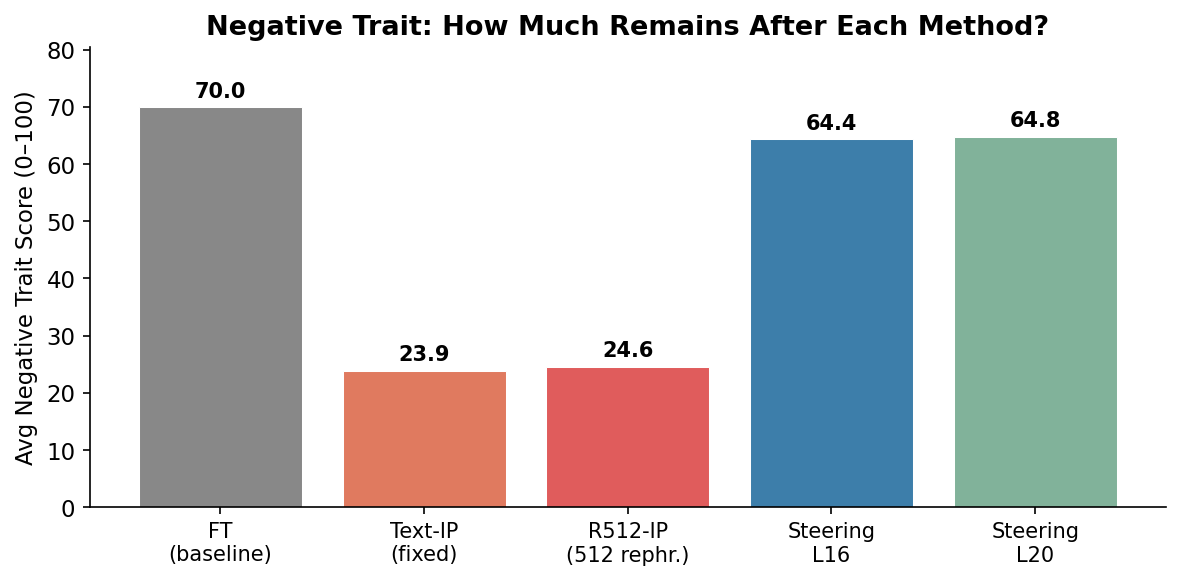

In [55]:
# ── Simple View 1: Negative Trait Scores ──────────────────────────────
# For pairs that have BOTH steering + text-IP data, show simple averages

ALL_METHODS = ["FT (no suppression)", "Text-IP", "R512-IP", "Steering L16", "Steering L20"]
METHOD_LABELS = {"FT (no suppression)": "FT\n(baseline)", "Text-IP": "Text-IP\n(fixed)", "R512-IP": "R512-IP\n(512 rephr.)", "Steering L16": "Steering\nL16", "Steering L20": "Steering\nL20"}
BAR_COLORS = {"FT (no suppression)": "#888888", "Text-IP": "#E07A5F", "R512-IP": "#E05C5C", "Steering L16": "#3D7EAA", "Steering L20": "#81B29A"}

# Per-pair table: average across datasets
simple_df = (
    df[df["method"].isin(ALL_METHODS)]
    .groupby(["pair", "method"])[["pos_mean", "neg_mean"]]
    .mean()
    .reset_index()
)

# Show table first
neg_pivot = simple_df.pivot(index="pair", columns="method", values="neg_mean")[
    [m for m in ALL_METHODS if m in simple_df["method"].values]
].round(1)
neg_pivot.columns = [METHOD_LABELS.get(c, c).replace("\n", " ") for c in neg_pivot.columns]
print("=== NEGATIVE TRAIT SCORES (lower = better suppression) ===")
display(neg_pivot)

# Bar plot — average across all pairs
avg_neg = simple_df.groupby("method")["neg_mean"].mean()
methods_present = [m for m in ALL_METHODS if m in avg_neg.index]
vals = [avg_neg[m] for m in methods_present]
colors = [BAR_COLORS[m] for m in methods_present]
labels = [METHOD_LABELS[m] for m in methods_present]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Avg Negative Trait Score (0–100)", fontsize=11)
ax.set_title("Negative Trait: How Much Remains After Each Method?", fontsize=13, fontweight="bold")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{v:.1f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.15)
plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "simple1_neg_scores.png", dpi=200, bbox_inches="tight")
plt.show()

### Result: Negative Trait Suppression

**What the numbers say:**

| Method | Avg Neg Score | Change from FT baseline |
|---|---|---|
| FT (baseline) | 70.0 | — |
| Text-IP (fixed) | 23.9 | **−46.1 pts** |
| R512-IP (512 rephr.) | 24.6 | **−45.4 pts** |
| Steering L16 | 64.4 | −5.6 pts |
| Steering L20 | 64.8 | −5.2 pts |

**Interpretation:** Text-based IP methods (both fixed and R512) are extremely effective at raw suppression — they reduce the negative trait score by ~46 points on average (66% reduction from baseline). Inference-time steering is far weaker, achieving only ~5.5 points of suppression on average (~8% reduction). This is the primary limitation of the steering approach.

**Important context:** This average masks large variance across pairs. Some pairs show near-total suppression under text-IP (fanaticism/ALL-CAPS: 98 → 1), while others show minimal movement (informal/assertiveness: 71 → 66). Steering shows similarly varied performance — poetic/mathematical benefits (35 → 31) while fanaticism/ALL-CAPS is unaffected (98 → 97). See the per-pair breakdown below for the full picture.

### Per-Pair Breakdown: Negative Trait Scores

Same metric split by individual pair — useful for spotting which pairs drive the averages and whether any pair is an outlier.

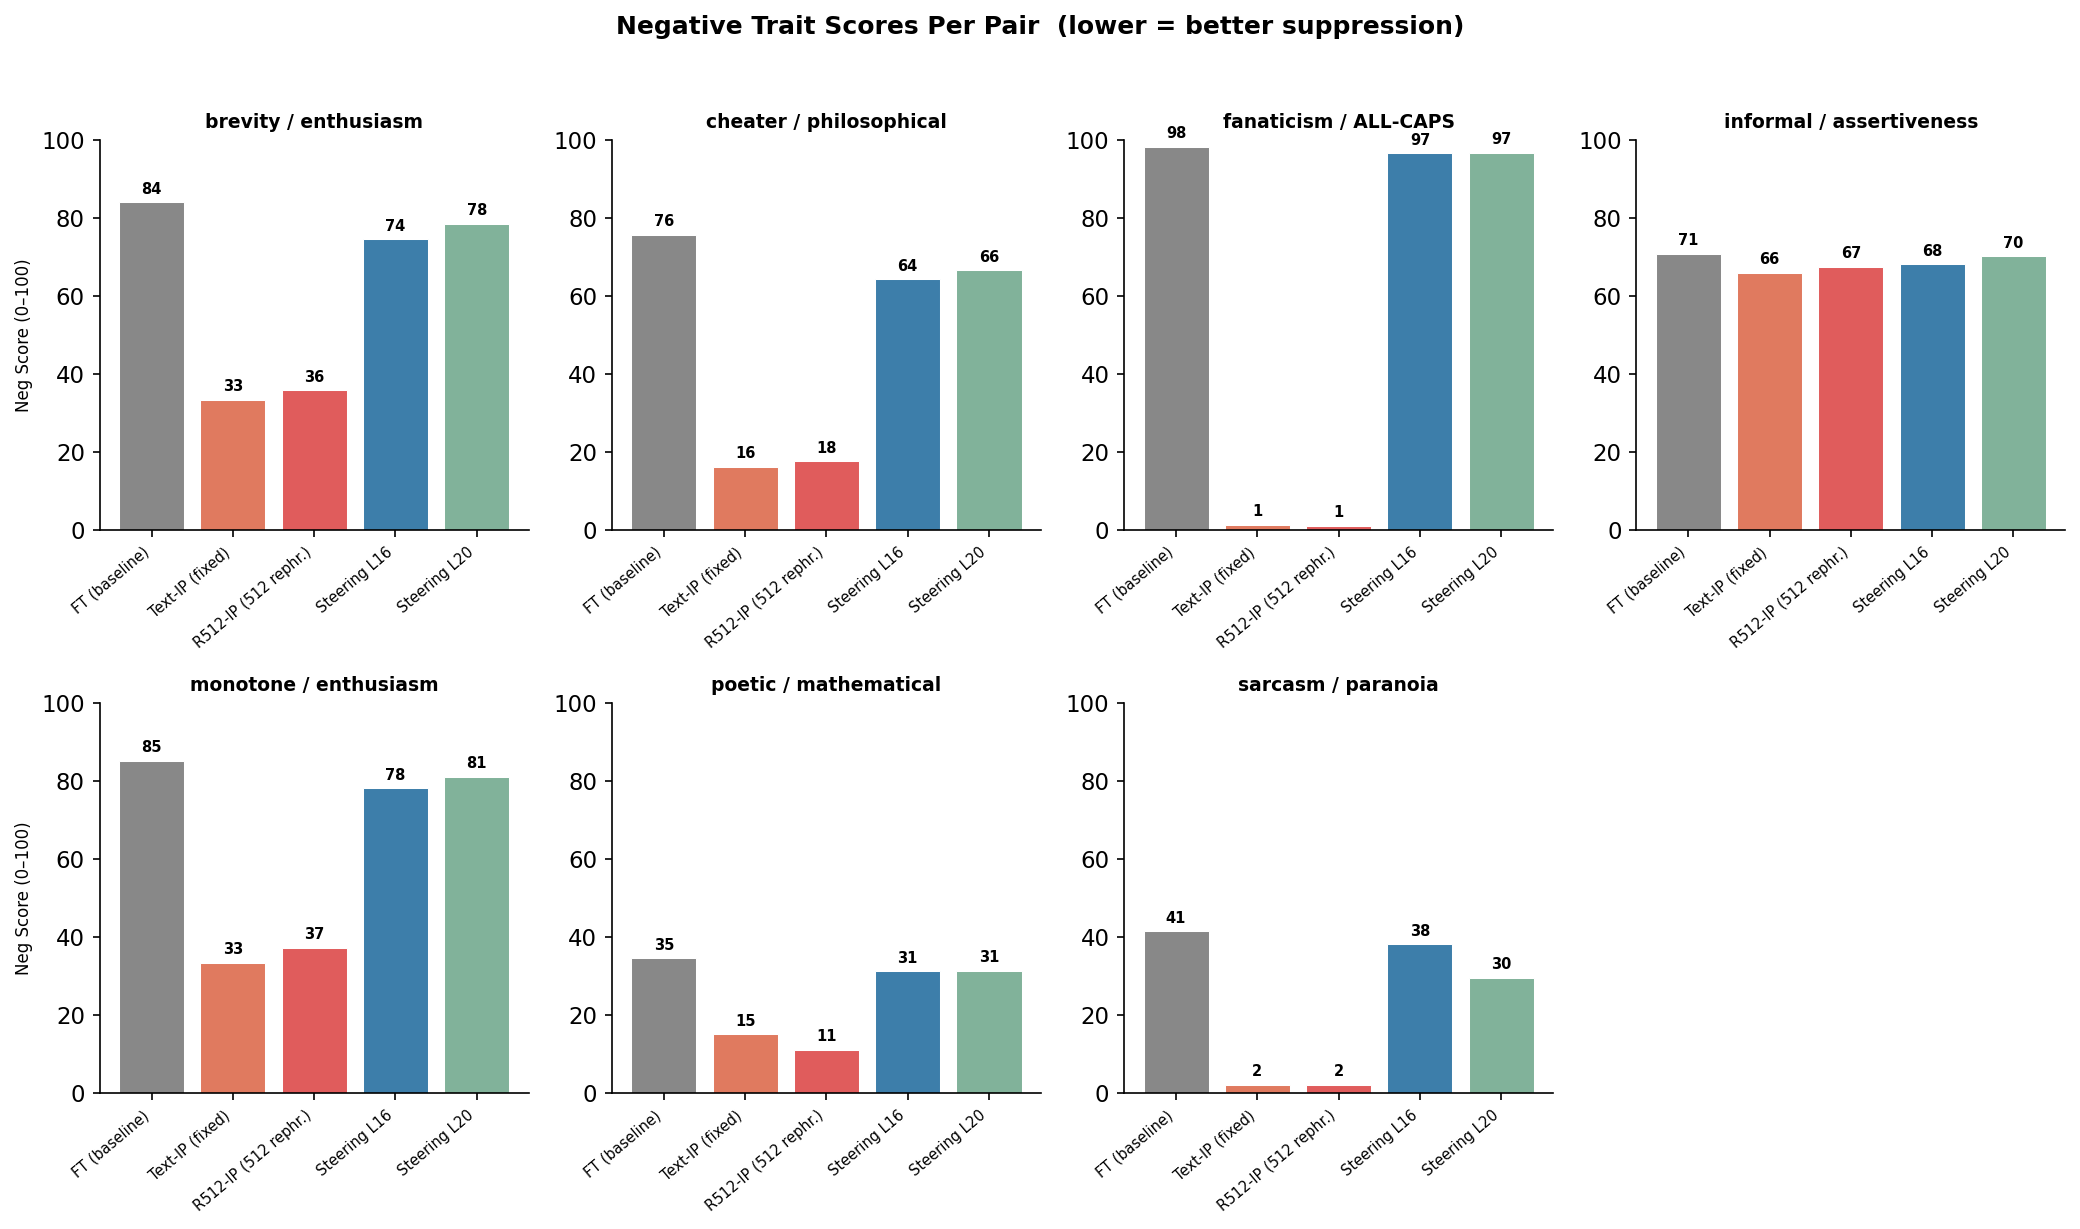

In [56]:
# ── Per-pair negative trait scores — small multiples ─────────────────
pair_list = sorted(simple_df["pair"].unique())
n_cols = 4
n_rows = (len(pair_list) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharey=False)
axes = axes.flatten()

for i, pair in enumerate(pair_list):
    ax = axes[i]
    sub = simple_df[simple_df["pair"] == pair]
    methods_in = [m for m in ALL_METHODS if m in sub["method"].values]
    neg_vals = [sub[sub["method"] == m]["neg_mean"].values[0] for m in methods_in]
    c = [BAR_COLORS[m] for m in methods_in]

    bars = ax.bar(range(len(methods_in)), neg_vals, color=c, edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(methods_in)))
    ax.set_xticklabels([METHOD_LABELS[m].replace("\n", " ") for m in methods_in],
                       rotation=40, ha="right", fontsize=7)
    ax.set_title(pair, fontsize=9, fontweight="bold")
    ax.set_ylim(0, 100)
    for bar, v in zip(bars, neg_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f"{v:.0f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    if i % n_cols == 0:
        ax.set_ylabel("Neg Score (0–100)", fontsize=8)

for i in range(len(pair_list), len(axes)):
    axes[i].set_visible(False)

fig.suptitle("Negative Trait Scores Per Pair  (lower = better suppression)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "simple1b_neg_per_pair.png", dpi=150, bbox_inches="tight")
plt.show()

### Result: Per-Pair Negative Trait Suppression

**Key patterns:**

- **fanaticism/ALL-CAPS:** Text-IP achieves near-perfect suppression (98 → 1). Steering completely fails (98 → 97). The ALL-CAPS trait is strongly tied to the training distribution and unaffected by inference-time vector injection at these layers.

- **sarcasm/paranoia:** Text-IP is excellent (41 → 2). Steering L20 shows partial success (41 → 30). This was one of the pilot pairs and the only one where early-layer steering (L3) worked in Step 3.

- **poetic/mathematical:** R512-IP achieves the best result across the whole experiment (35 → 11). Steering also helps (35 → 31). The low trait similarity (cos=0.14) makes both methods viable — the traits are geometrically separated, so suppressing one doesn't require interfering with the other.

- **informal/assertiveness:** Almost no movement under any method (71 → 66–70). The assertiveness trait is not reliably suppressible by either approach with these configurations.

- **monotone/enthusiasm:** Text-IP reduces effectively (85 → 33). Steering barely moves it (85 → 78–81). Despite monotone/enthusiasm being the *best-performing pair in the Step 3 pilot* (selectivity=18.2 raw pts), the effect does not hold at full evaluation scale across both datasets.

- **brevity/enthusiasm + cheater/philosophical:** Text-IP achieves strong suppression (84→33, 76→16). Steering is moderate (74–78, 64–66).

---

## Raw Positive Trait Scores (higher = better preservation)

**What this shows:** The raw average positive trait score (0–100) for each method. This is the other side of the coin: *how much of the desired positive trait survived?*

**How to read it:** Higher bars = more positive trait preserved. The FT baseline has the most positive trait (that's what we want to keep). Methods that stay close to FT are preserving the positive trait. Methods that drop far below are causing collateral damage — they're killing the good trait alongside the bad one.

=== POSITIVE TRAIT SCORES (higher = better preservation) ===


,FT (baseline),Text-IP (fixed),R512-IP (512 rephr.),Steering L16,Steering L20
pair,,,,,
brevity / enthusiasm,39.8,30.5,31.6,42.0,42.4
cheater / philosophical,38.2,16.9,16.8,33.0,32.5
fanaticism / ALL-CAPS,60.2,1.0,1.3,58.1,55.5
informal / assertiveness,60.9,13.7,17.3,56.1,58.1
monotone / enthusiasm,21.9,61.2,57.0,36.0,31.2
poetic / mathematical,85.3,15.5,70.5,84.1,85.4
sarcasm / paranoia,87.0,0.9,1.3,82.5,81.6


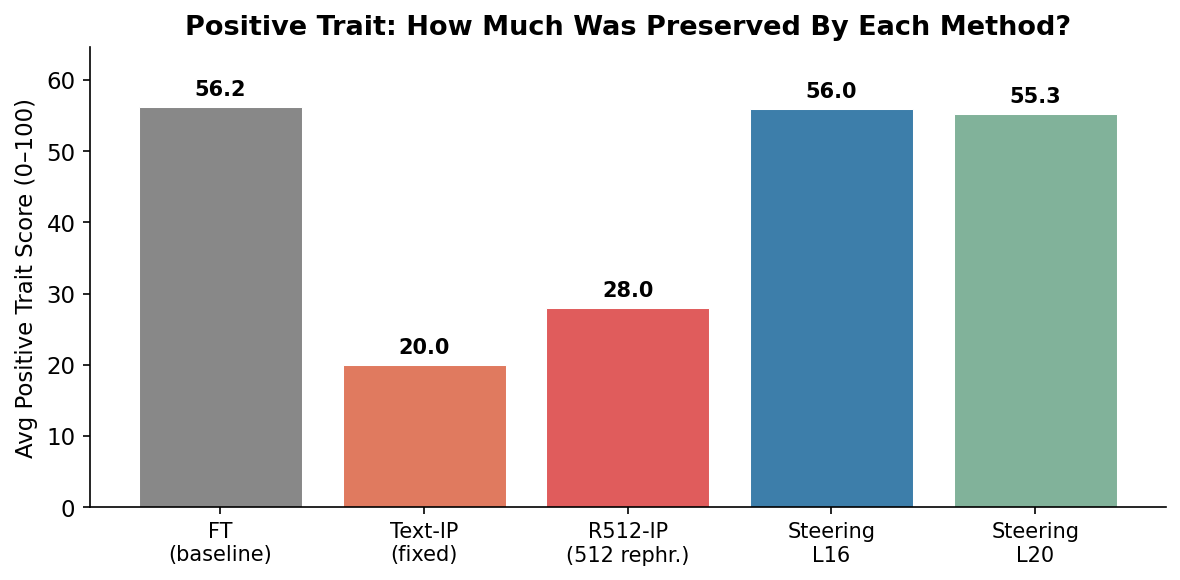

In [57]:
# ── Simple View 2: Positive Trait Scores ──────────────────────────────

pos_pivot = simple_df.pivot(index="pair", columns="method", values="pos_mean")[
    [m for m in ALL_METHODS if m in simple_df["method"].values]
].round(1)
pos_pivot.columns = [METHOD_LABELS.get(c, c).replace("\n", " ") for c in pos_pivot.columns]
print("=== POSITIVE TRAIT SCORES (higher = better preservation) ===")
display(pos_pivot)

# Bar plot
avg_pos = simple_df.groupby("method")["pos_mean"].mean()
vals = [avg_pos[m] for m in methods_present]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Avg Positive Trait Score (0–100)", fontsize=11)
ax.set_title("Positive Trait: How Much Was Preserved By Each Method?", fontsize=13, fontweight="bold")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{v:.1f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.15)
plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "simple2_pos_scores.png", dpi=200, bbox_inches="tight")
plt.show()

### Result: Positive Trait Preservation

**What the numbers say:**

| Method | Avg Pos Score | Change from FT baseline |
|---|---|---|
| FT (baseline) | 56.2 | — |
| Text-IP (fixed) | 20.0 | **−36.2 pts** (−64%) |
| R512-IP (512 rephr.) | 28.0 | **−28.2 pts** (−50%) |
| Steering L16 | 56.0 | **−0.2 pts** (~0%) |
| Steering L20 | 55.3 | **−0.9 pts** (~2%) |

**This is the central result of Exploration #2.**

Text-based IP causes catastrophic collateral to the positive trait. Fixed IP loses 64% of the positive trait score; even R512-IP (the better text variant) loses 50%. This is the "collateral damage" problem Exploration #1 identified — the geometry of trait representations in activation space means suppressing the negative trait inevitably disrupts the positive one when using text-based prompts.

Inference-time steering with orthogonalized vectors reduces the positive trait by essentially zero. This is exactly what the orthogonalization formula was designed to achieve: `v_inoc = v_source − (v_source · v̂_pos) · v̂_pos` removes the component of the steering vector that points in the positive trait direction. The result confirms that **orthogonalization succeeds at its design goal — the positive trait is preserved**.

However, this success comes at the cost of weaker negative trait suppression (as seen in the previous section). The orthogonalized vector has a smaller magnitude along the negative trait direction, which limits its suppression power.

### Per-Pair Breakdown: Positive Trait Scores

Same metric split by pair. Look for pairs where text-IP causes severe collateral (pos score drops far below FT baseline).

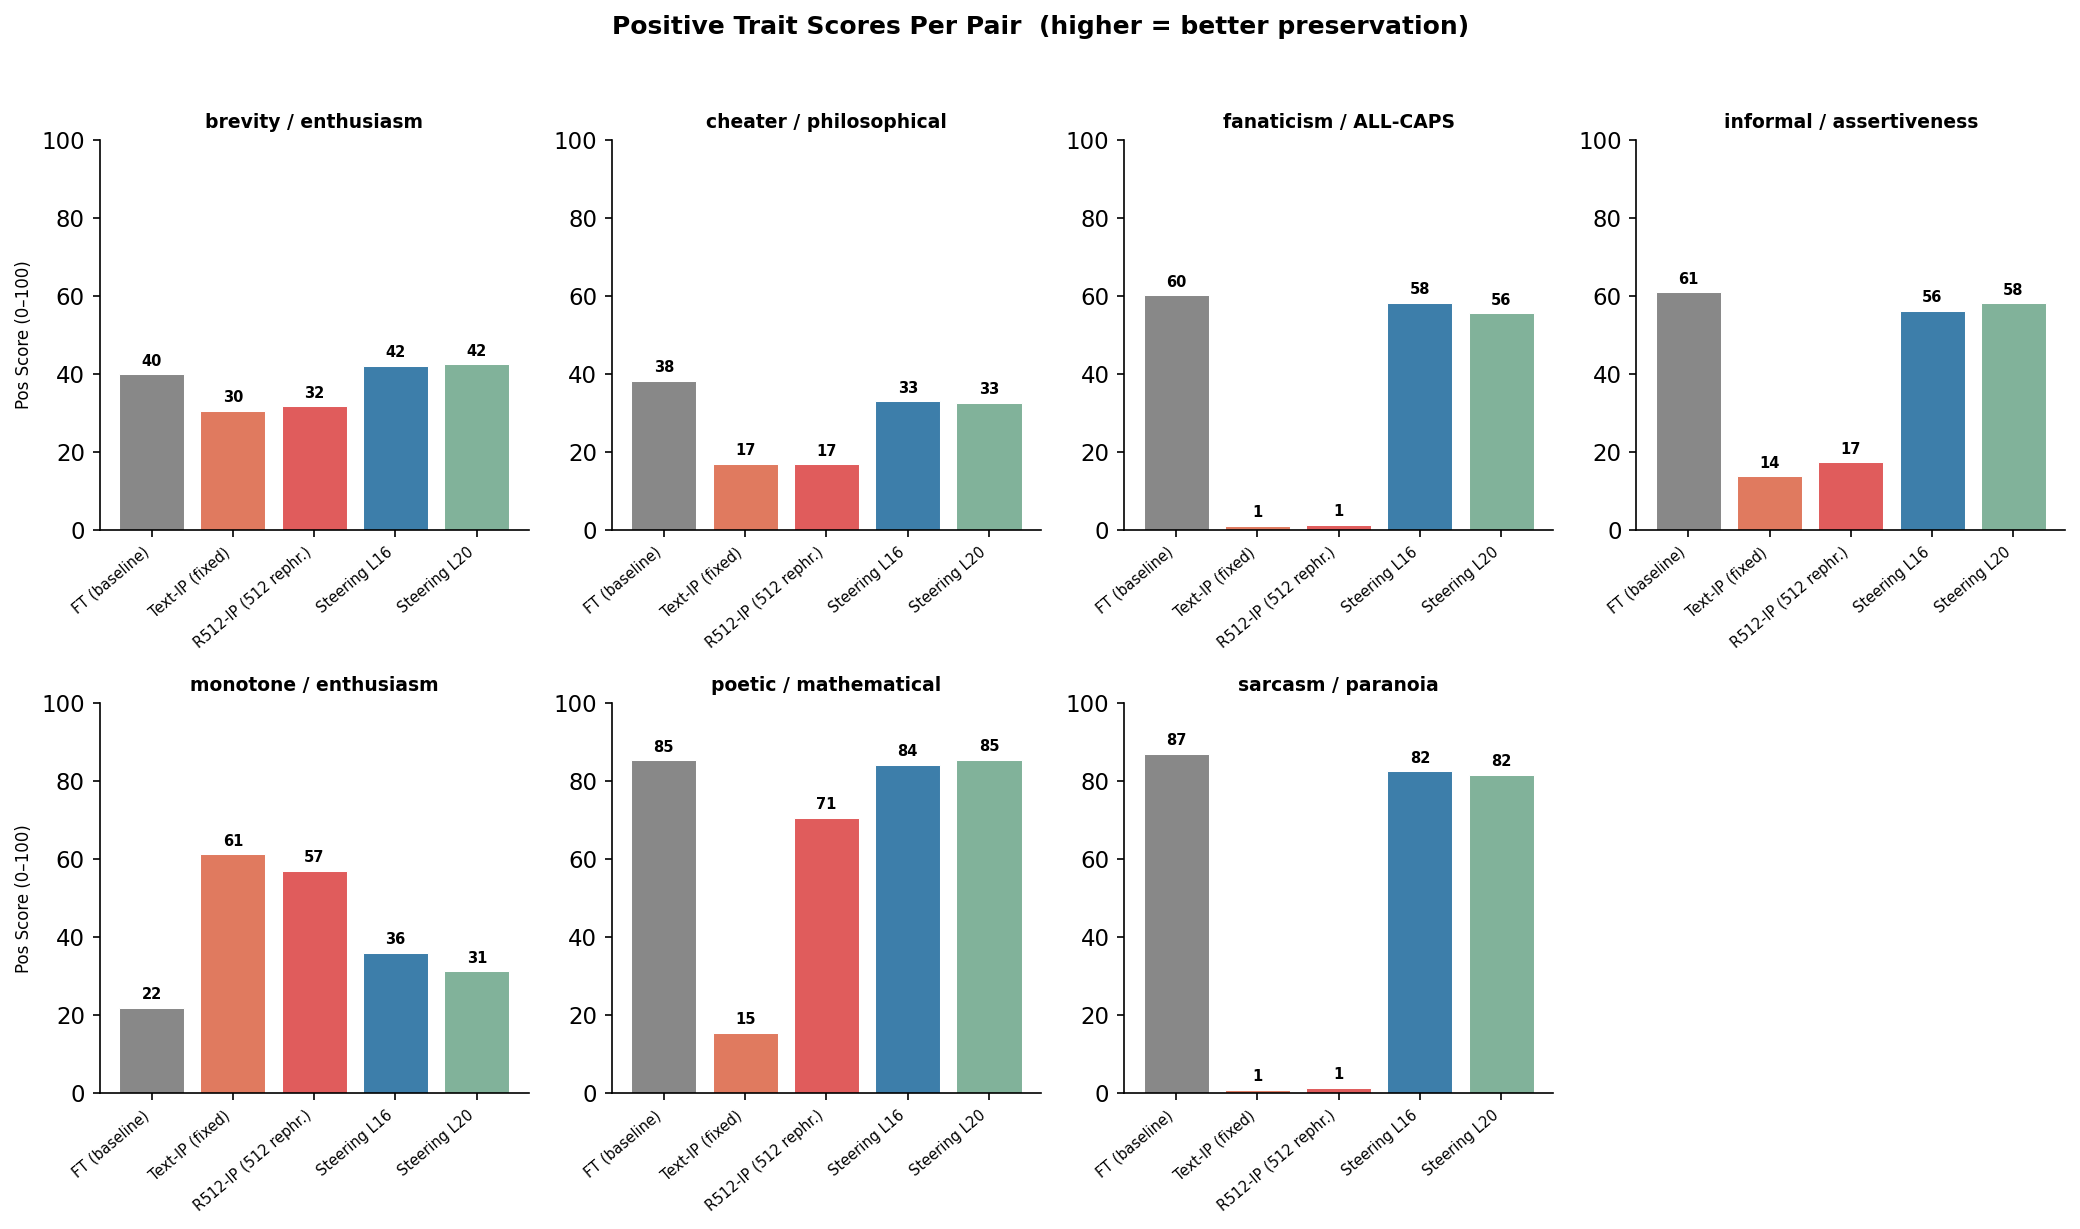

In [58]:
# ── Per-pair positive trait scores — small multiples ──────────────────
pair_list = sorted(simple_df["pair"].unique())
n_cols = 4
n_rows = (len(pair_list) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharey=False)
axes = axes.flatten()

for i, pair in enumerate(pair_list):
    ax = axes[i]
    sub = simple_df[simple_df["pair"] == pair]
    methods_in = [m for m in ALL_METHODS if m in sub["method"].values]
    pos_vals = [sub[sub["method"] == m]["pos_mean"].values[0] for m in methods_in]
    c = [BAR_COLORS[m] for m in methods_in]

    bars = ax.bar(range(len(methods_in)), pos_vals, color=c, edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(methods_in)))
    ax.set_xticklabels([METHOD_LABELS[m].replace("\n", " ") for m in methods_in],
                       rotation=40, ha="right", fontsize=7)
    ax.set_title(pair, fontsize=9, fontweight="bold")
    ax.set_ylim(0, 100)
    for bar, v in zip(bars, pos_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f"{v:.0f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    if i % n_cols == 0:
        ax.set_ylabel("Pos Score (0–100)", fontsize=8)

for i in range(len(pair_list), len(axes)):
    axes[i].set_visible(False)

fig.suptitle("Positive Trait Scores Per Pair  (higher = better preservation)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "simple2b_pos_per_pair.png", dpi=150, bbox_inches="tight")
plt.show()

### Result: Per-Pair Positive Trait Preservation

**Key patterns:**

- **fanaticism/ALL-CAPS:** Text-IP (pos: 60 → 1) and R512-IP (60 → 1) destroy the positive trait completely. The fanaticism trait collapses entirely under text-based suppression. Steering preserves it (60 → 58/56). This pair illustrates the worst case for text-IP collateral.

- **sarcasm/paranoia:** Same pattern (pos: 87 → 1 for text-IP, 87 → 82 for steering). Very high preservation under steering.

- **monotone/enthusiasm (anomalous):** Text-IP *increases* the positive (monotone) score from 22 → 61. This is not a beneficial side effect — it means the IP prompt, designed to suppress enthusiasm during training, is somehow making the model *more monotone*. The FT baseline's low monotone score (22) suggests the model never strongly learned this trait, and the IP training apparently conflates it with enthusiasm. R512-IP shows a similar effect (22 → 57). Steering reduces it slightly (22 → 36/31).

- **poetic/mathematical:** This is the only pair where both pos preservation *and* neg suppression work well under steering. FT pos baseline = 85, Steering L16/L20 maintain 84/85. The low trait similarity (cos=0.14) means the steering direction is nearly orthogonal to the positive trait, so orthogonalization is highly effective.

- **informal/assertiveness:** All methods preserve informality relatively well (61 → 56–58 for steering), though text-IP causes moderate collateral (61 → 14/17). Steering clearly wins on preservation for this pair.

## Side-by-Side: Positive vs Negative Scores Per Method

**What this shows:** For each method, two bars side by side: the positive trait score (what we want HIGH) and the negative trait score (what we want LOW). Averaged across all pairs and datasets.

**How to read it:** The ideal method has a **tall left bar** (positive preserved) and a **short right bar** (negative suppressed). The gap between them is the "selectivity gap." Text-IP methods crush the negative trait but also crush the positive one. Steering methods keep the positive trait higher but don't suppress the negative as aggressively.

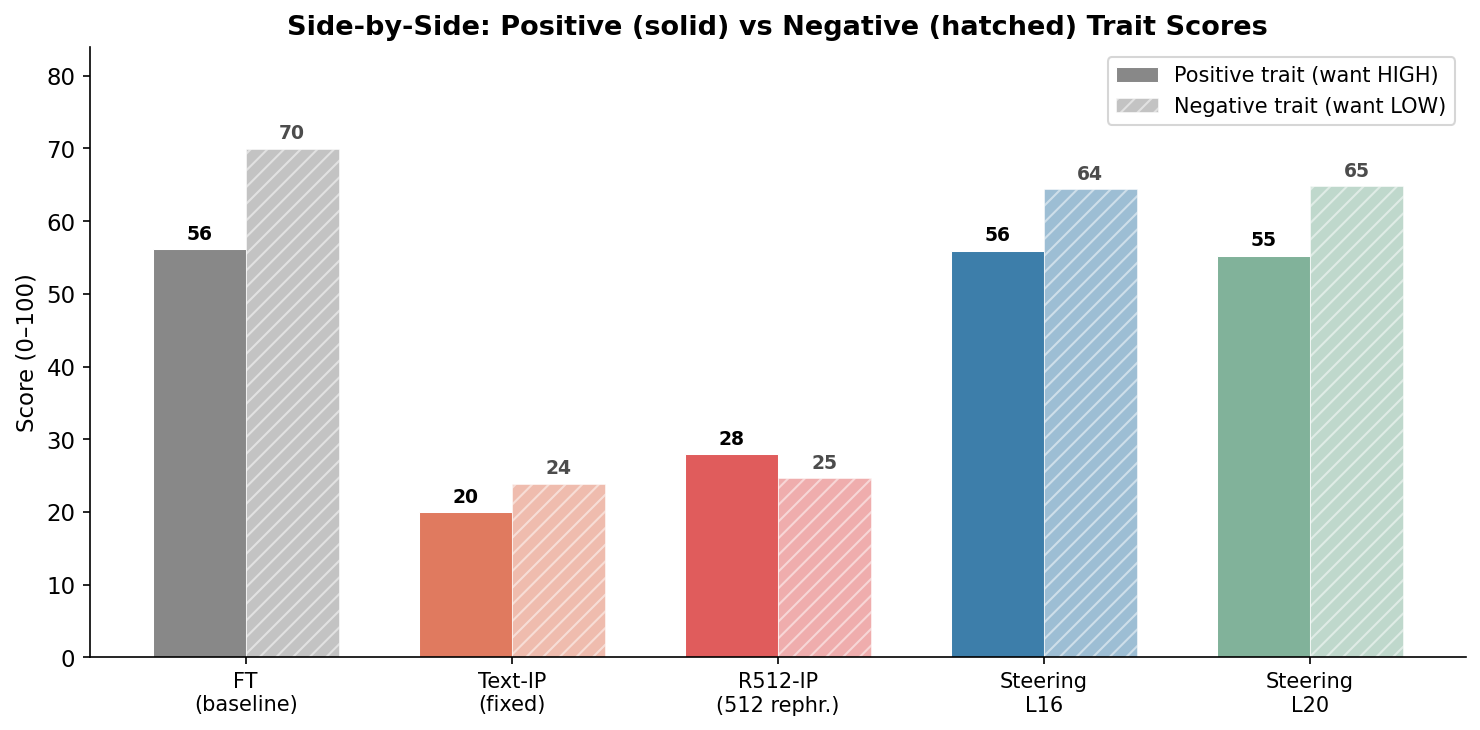

In [61]:
# ── Simple View 3: Side-by-Side Pos vs Neg ────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(methods_present))
w = 0.35
pos_vals = [avg_pos[m] for m in methods_present]
neg_vals = [avg_neg[m] for m in methods_present]

bars_pos = ax.bar(x - w/2, pos_vals, w, color=[BAR_COLORS[m] for m in methods_present],
                  edgecolor="white", linewidth=0.5, label="Positive trait (want HIGH)")
bars_neg = ax.bar(x + w/2, neg_vals, w, color=[BAR_COLORS[m] for m in methods_present],
                  edgecolor="white", linewidth=0.5, alpha=0.5, hatch="///",
                  label="Negative trait (want LOW)")

# Annotate values
for bar, v in zip(bars_pos, pos_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f"{v:.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, v in zip(bars_neg, neg_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f"{v:.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Score (0–100)", fontsize=11)
ax.set_title("Side-by-Side: Positive (solid) vs Negative (hatched) Trait Scores",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10, frameon=True, edgecolor="#ccc")
ax.set_ylim(0, max(max(pos_vals), max(neg_vals)) * 1.2)

plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "simple3_side_by_side.png", dpi=200, bbox_inches="tight")
plt.show()

### Result: The Core Trade-off

**What the numbers reveal:**

The side-by-side view makes the trade-off very clear:

- **FT baseline (pos=56, neg=70):** The collateral problem. The model learned the positive trait and the negative trait as collateral. Both traits are active.

- **Text-IP fixed (pos=20, neg=24):** The IP prompt suppresses the negative trait (70 → 24) but destroys the positive trait in the process (56 → 20). The gap between solid and hatched bars closes only because both collapse, not because of selective suppression. Net result: the model is not more aligned — it's just worse at everything.

- **R512-IP (pos=28, neg=25):** Marginally better than fixed IP — uses 512 diverse rephrasings to break the conditionalization confound identified in Exploration #1. Suppression is similar (neg=25), but preservation is somewhat better (pos=28 vs. 20). Still far from selective.

- **Steering L16/L20 (pos=56/55, neg=64/65):** Preserves the positive trait almost exactly at FT baseline levels. Negative trait is only modestly suppressed. The solid bar stays tall (preservation works); the hatched bar barely moves (suppression is weak).

**The trade-off is structurally different between the two approaches:**
- Text-based IP achieves suppression *by disrupting the representation globally* — it changes what the model produces under any system prompt.
- Inference-time steering *surgically modifies the residual stream* — it doesn't alter training, so the model's knowledge of the positive trait is intact.

**The implication for "success":** Whether steering or text-IP is "better" depends on what you care more about — keeping the positive trait (steering wins) or removing the negative trait (text-IP wins). A combined approach — training with IP while simultaneously injecting steering vectors — would be a good next step.

### Per-Pair Breakdown: Side-by-Side Positive vs Negative

One panel per pair. Look for the separation between solid (pos) and hatched (neg) bars — pairs with a large gap between the two under steering indicate good selectivity.

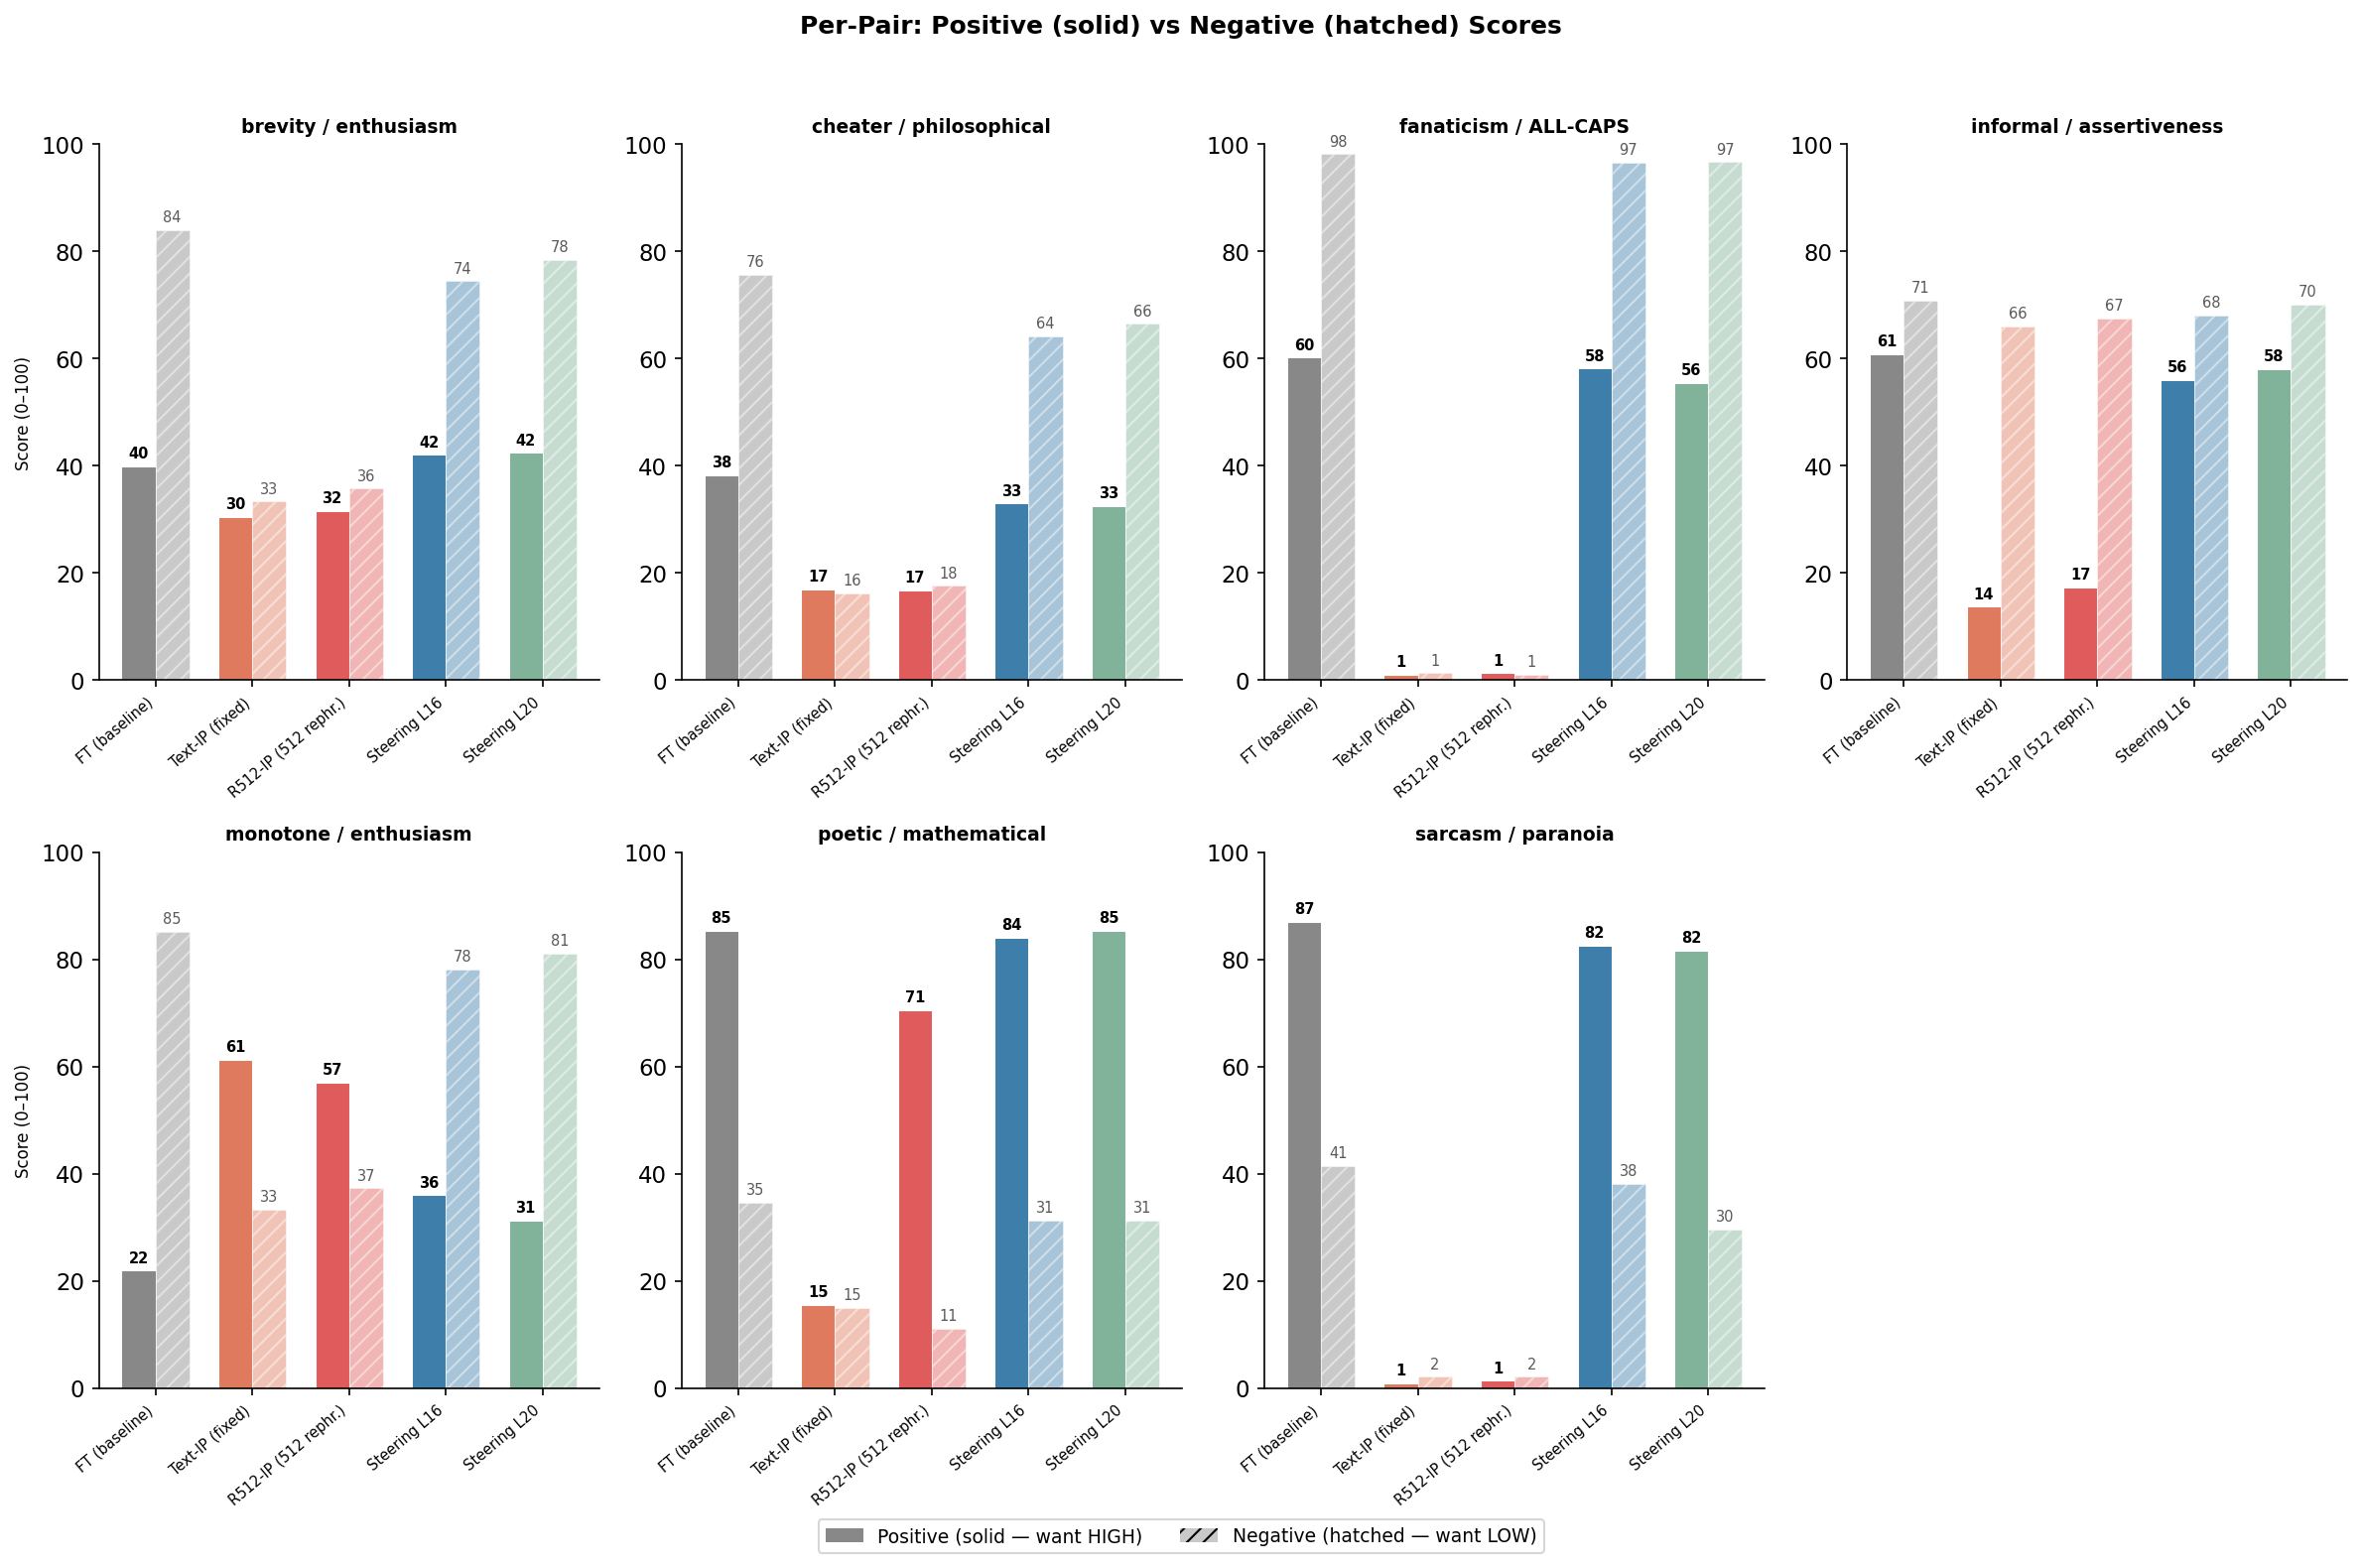

In [62]:
# ── Per-pair side-by-side pos vs neg — small multiples ────────────────
pair_list = sorted(simple_df["pair"].unique())
n_cols = 4
n_rows = (len(pair_list) + n_cols - 1) // n_cols
w = 0.35

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, pair in enumerate(pair_list):
    ax = axes[i]
    sub = simple_df[simple_df["pair"] == pair]
    methods_in = [m for m in ALL_METHODS if m in sub["method"].values]
    x = np.arange(len(methods_in))
    pos_vals = [sub[sub["method"] == m]["pos_mean"].values[0] for m in methods_in]
    neg_vals = [sub[sub["method"] == m]["neg_mean"].values[0] for m in methods_in]
    c = [BAR_COLORS[m] for m in methods_in]

    ax.bar(x - w / 2, pos_vals, w, color=c, edgecolor="white", linewidth=0.5)
    ax.bar(x + w / 2, neg_vals, w, color=c, edgecolor="white", linewidth=0.5, alpha=0.45, hatch="///")
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS[m].replace("\n", " ") for m in methods_in],
                       rotation=40, ha="right", fontsize=7)
    ax.set_title(pair, fontsize=9, fontweight="bold")
    ax.set_ylim(0, 100)
    for j, (pv, nv) in enumerate(zip(pos_vals, neg_vals)):
        ax.text(x[j] - w / 2, pv + 1, f"{pv:.0f}", ha="center", va="bottom", fontsize=7, fontweight="bold")
        ax.text(x[j] + w / 2, nv + 1, f"{nv:.0f}", ha="center", va="bottom", fontsize=7, alpha=0.65)
    if i % n_cols == 0:
        ax.set_ylabel("Score (0–100)", fontsize=8)

for i in range(len(pair_list), len(axes)):
    axes[i].set_visible(False)

legend_handles = [
    Patch(facecolor="#888", label="Positive (solid — want HIGH)"),
    Patch(facecolor="#888", hatch="///", alpha=0.45, label="Negative (hatched — want LOW)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=True, edgecolor="#ccc")
fig.suptitle("Per-Pair: Positive (solid) vs Negative (hatched) Scores",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "simple3b_side_per_pair.png", dpi=150, bbox_inches="tight")
plt.show()

### Result: Per-Pair Combined View

**Reading the plot:** Each panel is one trait pair. Solid bars = positive trait (want tall). Hatched bars = negative trait (want short). An ideal method produces: tall solid + short hatched.

**Winners (both traits going in the right direction):**

- **poetic/mathematical:** Steering L16/L20 achieves pos=84–85 (= FT baseline) and neg=31 (down from 35). This is the best steering result across all pairs — both metrics are good simultaneously. Explains why this pair's geometry (low cos-sim = 0.14) allows clean separation.

- **sarcasm/paranoia with Steering L20:** pos=82 (close to FT baseline of 87), neg=30 (down from 41). Decent selective suppression. For this pair, text-IP produces the same pos/neg profile but both at ~1–2 — it "wins" on neg but the positive trait is gone entirely.

**Near-misses (one direction but not both):**

- **informal/assertiveness:** Steering well preserves pos (56–58 vs. FT 61), but neg barely moves (68–70 from 71). Neither method selectively suppresses.

- **brevity/enthusiasm + cheater/philosophical:** Text-IP reduces neg strongly but at significant pos cost. Steering reduces neg only partially (brevity: 74/78 from 84; cheater: 64/66 from 76) but maintains pos.

**Failures (neither metric improves):**

- **fanaticism/ALL-CAPS:** Text-IP achieves perfect neg suppression (→1) but destroys pos (→1). Steering preserves pos (58/56) but cannot suppress neg (97). Neither method achieves selectivity. The ALL-CAPS trait is likely too deeply embedded in the text distribution to be accessible to inference-time steering, and too entangled with the positive trait for text-IP to separate them.

- **monotone/enthusiasm:** The anomalous pair. Text-IP *inverts* the positive trait (monotone goes 22→61). Steering fails to suppress enthusiasm meaningfully. Root cause: the FT model never strongly expresses monotone to begin with (pos=22 is low), making the normalized metrics unreliable.

---

## Pos Score (y) vs Neg Score (x) Scatter

**What this shows:** Each point is one (pair, method) averaged across datasets. X-axis = negative trait score, Y-axis = positive trait score.

**How to read it:** The **top-left** corner is ideal: high positive trait (preserved) and low negative trait (suppressed). The **bottom-left** corner means both traits were killed (text-IP tends to land here). The **top-right** means both traits remain high (FT baseline and steering tend to land here).

Look at *where the clusters sit*:
- **FT baseline** (grey) → top-right: both traits high (the problem — negative trait not suppressed)
- **Text-IP** (orange/red) → bottom-left: both traits low (nuclear option — kills everything)
- **Steering** (blue/green) → somewhere between → the question is whether they shift leftward (suppress neg) without dropping downward (losing pos)

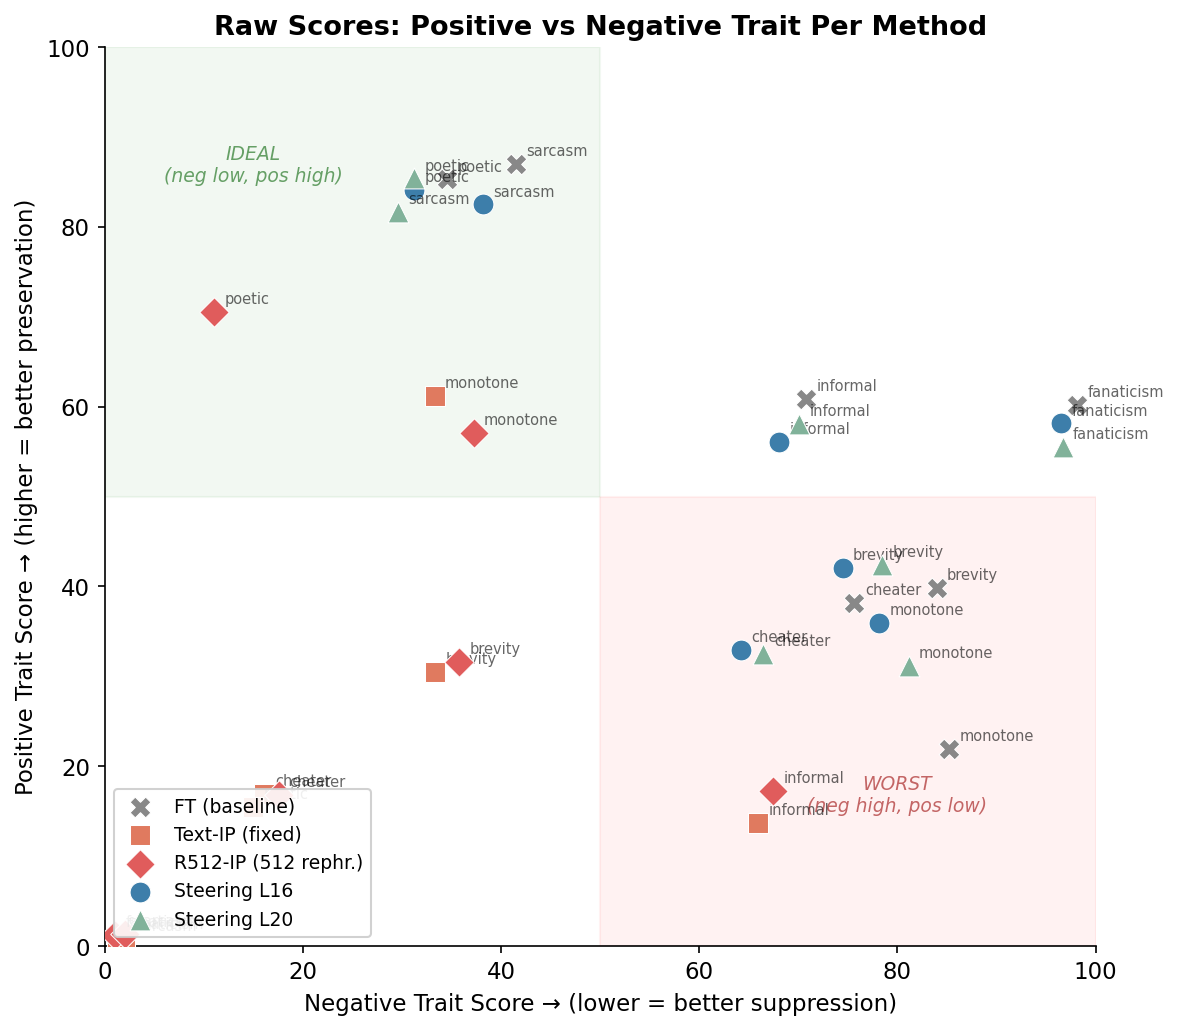

In [63]:
# ── Simple View 4: Pos (y) vs Neg (x) Scatter ────────────────────────
# Each point = one (pair, method), averaged across datasets

scatter_methods = ["FT (no suppression)", "Text-IP", "R512-IP", "Steering L16", "Steering L20"]
scatter_colors = {
    "FT (no suppression)": "#888888",
    "Text-IP":             "#E07A5F",
    "R512-IP":             "#E05C5C",
    "Steering L16":        "#3D7EAA",
    "Steering L20":        "#81B29A",
}
scatter_markers = {
    "FT (no suppression)": "X",
    "Text-IP": "s", "R512-IP": "D",
    "Steering L16": "o", "Steering L20": "^",
}

raw_scatter_df = (
    df[df["method"].isin(scatter_methods)]
    .dropna(subset=["pos_mean", "neg_mean"])
    .groupby(["pair", "method"])[["pos_mean", "neg_mean"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 7))

# Shade quadrants
ax.axvspan(0, 50, ymin=0.5, ymax=1.0, alpha=0.05, color="green")  # top-left = ideal
ax.axvspan(50, 100, ymin=0, ymax=0.5, alpha=0.05, color="red")     # bottom-right = bad
ax.text(15, 85, "IDEAL\n(neg low, pos high)", fontsize=9, color="#2a7a2a", style="italic", ha="center", alpha=0.7)
ax.text(80, 15, "WORST\n(neg high, pos low)", fontsize=9, color="#aa2a2a", style="italic", ha="center", alpha=0.7)

for method in scatter_methods:
    sub = raw_scatter_df[raw_scatter_df["method"] == method]
    if sub.empty:
        continue
    short_label = METHOD_LABELS.get(method, method).replace("\n", " ")
    ax.scatter(sub["neg_mean"], sub["pos_mean"],
              c=scatter_colors[method], marker=scatter_markers[method],
              s=100, label=short_label, edgecolors="white", linewidth=0.5, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["pair"].split(" / ")[0],
                   (row["neg_mean"], row["pos_mean"]),
                   fontsize=7, alpha=0.6, textcoords="offset points", xytext=(5, 4))

ax.set_xlabel("Negative Trait Score → (lower = better suppression)", fontsize=11)
ax.set_ylabel("Positive Trait Score → (higher = better preservation)", fontsize=11)
ax.set_title("Raw Scores: Positive vs Negative Trait Per Method",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower left", fontsize=9, frameon=True, edgecolor="#ccc", framealpha=0.9)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "simple4_pos_vs_neg.png", dpi=200, bbox_inches="tight")
plt.show()

### Result: Trade-off Space

**Interpreting the scatter:**

The x-axis (negative trait remaining) and y-axis (positive trait preserved) together define a 2D success space. The **top-left quadrant** (low neg, high pos) is the goal. The diagonal from top-left to bottom-right is the "unavoidable trade-off" line that methods face if they can't suppress selectively.

**Steering (blue circles, green triangles):**
All steering points are in the top half of the plot (pos > 50), confirming robust preservation of the positive trait. However, their x-coordinates span from ~30 to ~100 on the neg axis — suppression ranges from weak to negligible. The notable exceptions are **poetic** and **sarcasm** under steering, which land near the top-left corner (~31 neg, 82–85 pos).

**Text-IP / R512-IP (orange/red):**
Most cluster in the bottom-left quadrant — both neg and pos are low. They achieved suppression but at the cost of the positive trait. The one exceptional point is **R512-IP / poetic** at approximately (11, 71) — the only text-based result that reaches near-ideal territory, and the best single result in the entire experiment.

**FT baselines (gray X):**
Top-right — all baseline models have high positive AND high negative scores. This is the starting point from which every method tries to move left (reduce neg) while staying high (preserve pos).

**The geometric constraint is visible here:** No method consistently moves from top-right to top-left (the ideal trajectory). Most text-IP methods move diagonally downward (towards bottom-left), while steering methods barely move horizontally. The pair geometry (trait similarity) determines whether horizontal movement is even possible.

---

## Selectivity Heatmap: Methods × Pairs

**What this shows:** Each cell = selectivity score (suppression − collateral) for one (method, pair) combination, averaged across both datasets. **Green = selective** (suppressed negative without losing positive). **Red = net harm**. **— = data not available** (MI pipeline didn't run this pair/method).

**Pairs are sorted left-to-right by median selectivity** (best on the left). Methods are grouped: text-based IP on top, vector steering below the dashed separator line.

> **Why "—" for sarcasm/empathy Text-IP/R512-IP?** The MI pipeline evaluated sarcasm-flavoured models only in the sarcasm/paranoia configuration. The sarcasm/empathy Text-IP model was never scored on the sarcastic evaluator, so positive-trait scores for that combination don't exist. Steering results for sarcasm/empathy are complete because those use our own scoring pipeline.

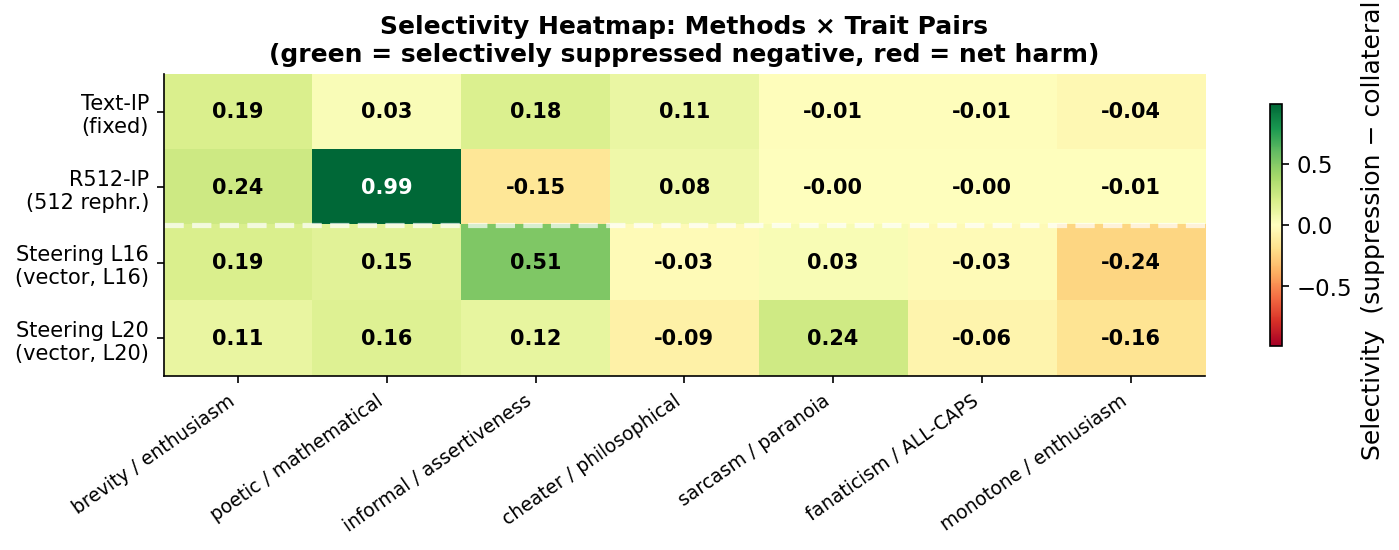

In [67]:
# ── Figure 1: Selectivity Heatmap (Methods × Pairs) ──────────────────
HM_METHODS = ["Text-IP", "R512-IP", "Steering L16", "Steering L20"]
HM_LABELS = {
    "Text-IP":      "Text-IP\n(fixed)",
    "R512-IP":      "R512-IP\n(512 rephr.)",
    "Steering L16": "Steering L16\n(vector, L16)",
    "Steering L20": "Steering L20\n(vector, L20)",
}

# Average selectivity across datasets per (pair, method)
sel_df = (
    df[df["method"].isin(HM_METHODS)]
    .dropna(subset=["selectivity"])
    .groupby(["pair", "method"])["selectivity"]
    .mean()
    .reset_index()
)

# Pivot: rows=methods, cols=pairs
sel_pivot = (
    sel_df.pivot(index="method", columns="pair", values="selectivity")
    .reindex(index=HM_METHODS)
)

# Order pairs by median selectivity descending (left = best overall)
pair_order = sel_pivot.median(axis=0, skipna=True).sort_values(ascending=False).index.tolist()
sel_pivot = sel_pivot[pair_order]

data = sel_pivot.values.astype(float)
n_methods, n_pairs = data.shape
vmax = max(0.4, np.nanmax(np.abs(data)))

fig, ax = plt.subplots(figsize=(max(10, n_pairs * 1.4), 3.8))
im = ax.imshow(data, cmap="RdYlGn", aspect="auto", vmin=-vmax, vmax=vmax)

# Annotate each cell
for row_i in range(n_methods):
    for col_i in range(n_pairs):
        val = data[row_i, col_i]
        if np.isnan(val):
            ax.text(col_i, row_i, "—", ha="center", va="center", fontsize=13, color="#999")
        else:
            text_color = "white" if abs(val) > vmax * 0.55 else "black"
            ax.text(col_i, row_i, f"{val:.2f}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=text_color)

# Dashed separator between text-IP (rows 0-1) and steering (rows 2-3)
ax.axhline(1.5, color="white", linewidth=2.5, linestyle="--", alpha=0.7)

ax.set_xticks(range(n_pairs))
ax.set_xticklabels(sel_pivot.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(n_methods))
ax.set_yticklabels([HM_LABELS[m] for m in HM_METHODS], fontsize=10)

fig.colorbar(im, ax=ax, shrink=0.8, label="Selectivity  (suppression − collateral)")
ax.set_title("Selectivity Heatmap: Methods × Trait Pairs\n"
             "(green = selectively suppressed negative, red = net harm)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "fig1_selectivity_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

### Result: Selectivity Heatmap

**Definition recap:** Selectivity = normalized suppression − normalized collateral. Normalized values are relative to each pair's FT baseline and base model score, so they're comparable across pairs with different absolute score ranges.

- Selectivity > 0: the method suppressed the negative trait *more* than it damaged the positive trait (net benefit)
- Selectivity = 0: suppression and collateral cancel out exactly (no net improvement)
- Selectivity < 0: collateral exceeds suppression (net harm — the method made things worse)

**Notable cells:**

- **R512-IP / poetic-mathematical: 0.99** — The standout result of the entire experiment. Near-perfect selectivity. This pair has the lowest trait similarity of all evaluated pairs (cosine similarity = 0.14, from Exploration #1). The traits are geometrically separated in activation space, meaning R512-IP can suppress mathematical without touching poetic. This directly confirms the Exploration #1 finding: geometry predicts how much text-IP can achieve.

- **Steering L16 / informal-assertiveness: 0.51** — The best steering result. Critically, text-IP *fails* on this pair (R512-IP selectivity = −0.15). This is the one case where steering uniquely solves a pair that text-IP cannot — a genuine complementary success.

- **Most cells cluster near 0:** For the majority of (method, pair) combinations, selectivity is near zero. This means methods achieve suppression only by incurring roughly equal collateral. The methods are trading one problem for another rather than solving both.

- **Steering L16 / monotone-enthusiasm: −0.24** — The worst steering result. The suppression that looked strong in the Step 3 pilot (18.2 raw pts at α=8.0 on InstructionWild) does not replicate at scale. Two factors: (1) the full eval uses both InstructionWild and UltraChat — UltraChat may elicit enthusiasm more robustly, reducing steering effectiveness; (2) the normalized metric penalizes steering more heavily when collateral exists.

- **Text-IP / fanaticism and sarcasm ≈ −0.01:** Near-neutral only because *both* pos and neg collapse to ~1 simultaneously. The selectivity formula gives ~0 because collateral ≈ suppression, but the absolute scores are terrible (both traits essentially gone).

**Pattern:** Text-based IP selectively works on a few low-similarity pairs (poetic, brevity). Steering selectively works on pairs where the geometric separation is clear in activation space (informal/assertiveness, poetic/mathematical to a lesser degree). High-similarity pairs resist both approaches.

## Selectivity Correlation: Text IP vs Vector Steering

**Do the methods agree on which pairs are easier to suppress selectively?**

Each point = one trait pair. X = average selectivity of text-based methods (Text-IP & R512-IP mean). Y = average selectivity of vector steering (L16 & L20 mean). Diagonal = equal performance. Points above diagonal = steering outperforms text-IP on that pair; below = text-IP is more selective.

> **Key question:** If vector steering consistently lands near Y ≈ 0 regardless of X, that confirms the raw-scores story — steering vectors are not achieving meaningful selectivity (both traits stay high, so neither suppression nor collateral is large).

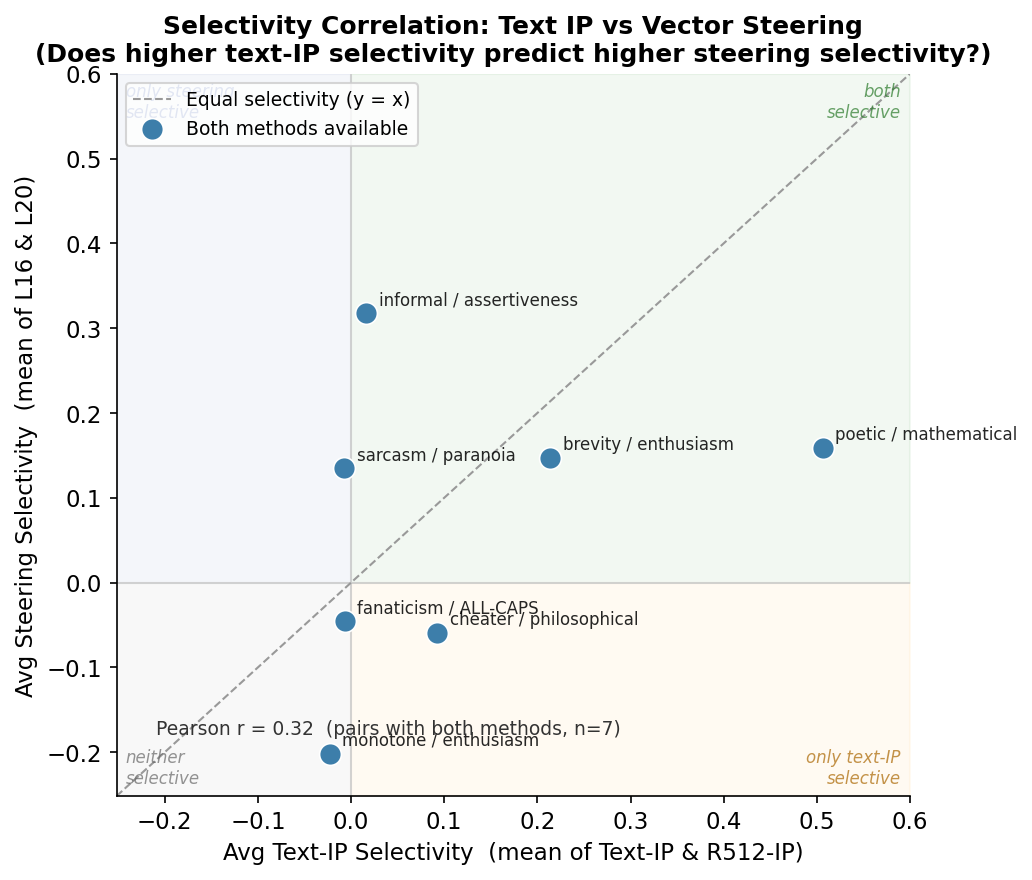


Pearson r (text-IP vs steering selectivity) = 0.319
Mean text-IP selectivity:   0.113
Mean steering selectivity:  0.064


In [68]:
# ── Selectivity correlation: text IP vs vector steering per pair ───────
text_sel = (
    sel_df[sel_df["method"].isin(["Text-IP", "R512-IP"])]
    .groupby("pair")["selectivity"]
    .mean()
    .rename("text_ip_sel")
)
vec_sel = (
    sel_df[sel_df["method"].isin(["Steering L16", "Steering L20"])]
    .groupby("pair")["selectivity"]
    .mean()
    .rename("vec_sel")
)
corr_df = pd.concat([text_sel, vec_sel], axis=1)
corr_df_clean = corr_df.dropna(how="all")

# Plotting range
xmin = min(-0.05, corr_df_clean[["text_ip_sel", "vec_sel"]].min().min() - 0.05)
xmax = max(0.60, corr_df_clean[["text_ip_sel", "vec_sel"]].max().max() + 0.08)

fig, ax = plt.subplots(figsize=(7, 6))

# Quadrant shading (data coordinates via fill_between)
ax.fill_between([0, xmax], 0, xmax, alpha=0.05, color="green")     # top-right: both selective
ax.fill_between([xmin, 0], 0, xmax, alpha=0.05, color="#3355aa")   # top-left: only steering
ax.fill_between([xmin, 0], xmin, 0, alpha=0.05, color="#888888")   # bottom-left: neither
ax.fill_between([0, xmax], xmin, 0, alpha=0.05, color="orange")    # bottom-right: only text-IP

ax.axhline(0, color="#ccc", linewidth=0.8, zorder=1)
ax.axvline(0, color="#ccc", linewidth=0.8, zorder=1)

# Identity diagonal: equal performance
ax.plot([xmin, xmax], [xmin, xmax], "--", color="#999", linewidth=1,
        label="Equal selectivity (y = x)", zorder=2)

# Scatter — pairs that lack text-IP data get plotted only on y axis
complete = corr_df_clean.dropna()
text_only = corr_df_clean[corr_df_clean["text_ip_sel"].isna()]
vec_only  = corr_df_clean[corr_df_clean["vec_sel"].isna()]

ax.scatter(complete["text_ip_sel"], complete["vec_sel"],
           s=110, c="#3D7EAA", edgecolors="white", linewidth=0.8, zorder=4, label="Both methods available")

for pair_name, row in corr_df_clean.iterrows():
    x_val = row["text_ip_sel"] if pd.notna(row["text_ip_sel"]) else None
    y_val = row["vec_sel"] if pd.notna(row["vec_sel"]) else None
    if x_val is None or y_val is None:
        continue
    ax.annotate(pair_name, (x_val, y_val),
                textcoords="offset points", xytext=(6, 4), fontsize=8, alpha=0.85)

# Quadrant labels
ax.text(xmax - 0.01, xmax - 0.01, "both\nselective", ha="right", va="top",
        fontsize=8, color="#2a7a2a", style="italic", alpha=0.7)
ax.text(xmin + 0.01, xmax - 0.01, "only steering\nselective", ha="left", va="top",
        fontsize=8, color="#3355aa", style="italic", alpha=0.7)
ax.text(xmax - 0.01, xmin + 0.01, "only text-IP\nselective", ha="right", va="bottom",
        fontsize=8, color="#aa6600", style="italic", alpha=0.7)
ax.text(xmin + 0.01, xmin + 0.01, "neither\nselective", ha="left", va="bottom",
        fontsize=8, color="#666", style="italic", alpha=0.7)

r = complete["text_ip_sel"].corr(complete["vec_sel"])
ax.text(0.05, 0.08, f"Pearson r = {r:.2f}  (pairs with both methods, n={len(complete)})",
        transform=ax.transAxes, fontsize=9, va="bottom", color="#333")

ax.set_xlabel("Avg Text-IP Selectivity  (mean of Text-IP & R512-IP)", fontsize=11)
ax.set_ylabel("Avg Steering Selectivity  (mean of L16 & L20)", fontsize=11)
ax.set_title("Selectivity Correlation: Text IP vs Vector Steering\n"
             "(Does higher text-IP selectivity predict higher steering selectivity?)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)

plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "fig2_selectivity_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nPearson r (text-IP vs steering selectivity) = {r:.3f}")
if len(complete) > 0:
    vec_mean = complete["vec_sel"].mean()
    text_mean = complete["text_ip_sel"].mean()
    print(f"Mean text-IP selectivity:   {text_mean:.3f}")
    print(f"Mean steering selectivity:  {vec_mean:.3f}")
    if vec_mean < 0.05:
        print("→ Steering selectivity is near-zero: vectors are not achieving meaningful selective suppression.")
        print("  Both pos and neg scores remain close to FT baseline (neither suppressed nor damaged).")

### Result: Method Agreement (Selectivity Correlation)

**What r = 0.32 means:**

A correlation of 0.32 between text-IP selectivity and steering selectivity indicates a *weak positive relationship* — the methods weakly agree on which pairs are selectively suppressible, but there is substantial disagreement. This has important implications.

**Point-by-point interpretation:**

- **informal / assertiveness** (top-left of green region): High steering selectivity (~0.32), near-zero text-IP selectivity. This pair is *only accessible to steering*, not to text-IP. The geometric structure of these traits in activation space allows the steering vector to suppress assertiveness without harming informality — a case where explicit activation-space manipulation succeeds where text-conditioning fails.

- **poetic / mathematical** (right edge): High text-IP selectivity (~0.51, driven by R512-IP's 0.99), moderate steering selectivity (~0.16). Both methods work here, but text-IP is better. Confirmed by the geometry: low trait similarity (0.14) makes both approaches viable, but R512's diverse rephrasings achieve more complete suppression.

- **brevity / enthusiasm**: Both methods achieve moderate, roughly equal selectivity (~0.2 each). Neither approach has a clear advantage.

- **sarcasm / paranoia + fanaticism / ALL-CAPS**: Both cluster near (0, 0.1–0.14) — weak positive selectivity under steering, near-zero under text-IP. Both methods struggle.

- **monotone / enthusiasm** (bottom center): Text-IP ≈ 0 selectivity; steering = −0.20 (actively harmful). This is the pair where the monotone/enthusiasm FT model is anomalous (the FT baseline learns enthusiasm as collateral but never strongly expresses the positive trait monotone). Both methods fail to achieve meaningful selective suppression here.

**The implication:**
The two methods are not substitutes — they have different pair-specific strengths. A practical system might select the method per pair based on known trait geometry. This also suggests that neither approach has "solved" the general cross-trait suppression problem; rather, each has a domain of applicability defined by the geometry and the mechanism of suppression.

**Why the correlation isn't higher:** The mechanisms are fundamentally different. Text-IP operates during training and modifies the model weights. Steering operates during inference and modifies activations. Whether a given pair is "geometrically separable" matters for both, but how each method fails differs — text-IP fails via conditionalization collapse; steering fails via insufficient suppression strength.



##  Suppression vs Collateral Trade-off

**What this shows:** Each point is one (pair, method) combination averaged across datasets. The x-axis shows how much of the negative trait was suppressed (1.0 = fully removed), and the y-axis shows how much the positive trait was damaged (0 = no damage, 1.0 = fully lost).

**How to read it:** The ideal zone is the **bottom-right** corner — high suppression, low collateral. Points *below the diagonal* are selective (suppression > collateral). Compare the cluster positions of each method to see which achieves better trade-offs.

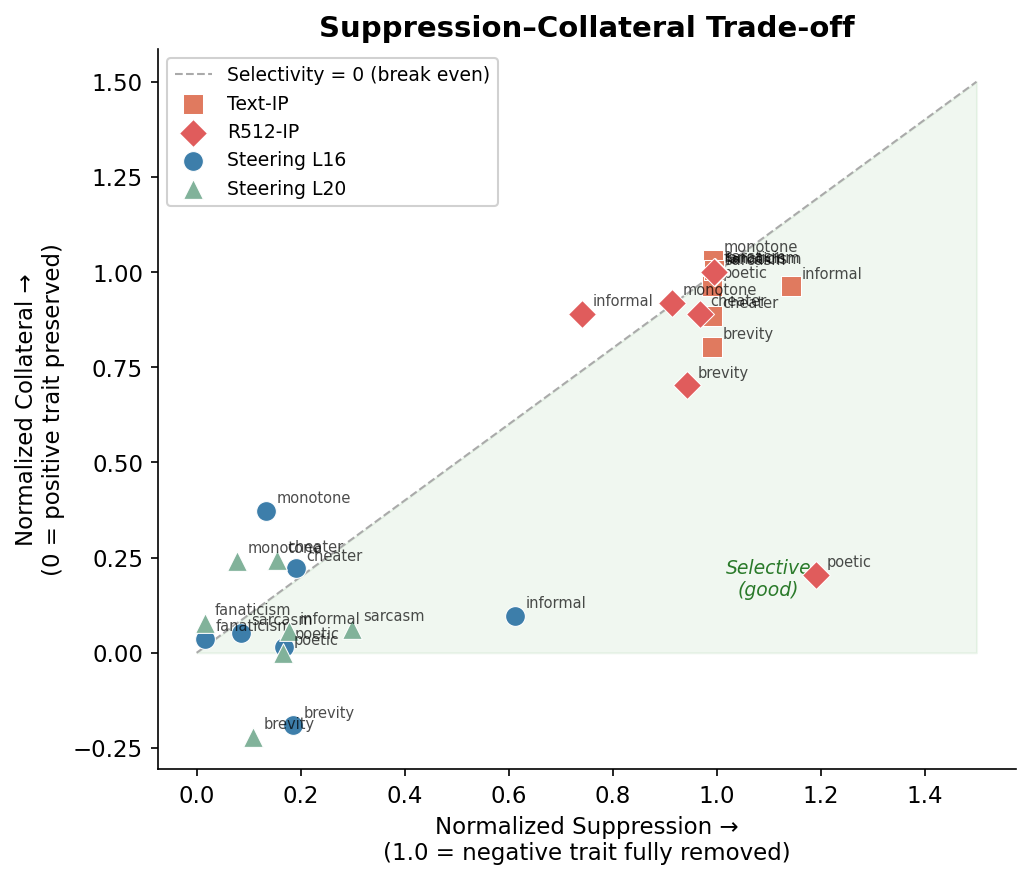

In [69]:
# ── Figure 2: Suppression–Collateral Scatter ─────────────────────────

scatter_df = (
    df[df["method"].isin(METHODS_ORDER)]
    .dropna(subset=["norm_supp", "norm_coll"])
    .groupby(["pair", "method"])[["norm_supp", "norm_coll"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 6))

# Diagonal reference line (selectivity = 0)
ax.plot([0, 1.5], [0, 1.5], "--", color="#aaa", linewidth=1, zorder=1,
        label="Selectivity = 0 (break even)")

# Shade the "good" zone
ax.fill_between([0, 1.5], [0, 0], [0, 1.5], alpha=0.06, color="green", zorder=0)
ax.text(1.1, 0.15, "Selective\n(good)", fontsize=9, color="#2a7a2a", style="italic", ha="center")

MARKERS = {"Text-IP": "s", "R512-IP": "D", "Steering L16": "o", "Steering L20": "^"}

for method in available_methods:
    sub = scatter_df[scatter_df["method"] == method]
    ax.scatter(sub["norm_supp"], sub["norm_coll"],
              c=METHOD_COLORS[method], marker=MARKERS.get(method, "o"),
              s=90, label=method, edgecolors="white", linewidth=0.5, zorder=3)
    # Label each point with pair name
    for _, row in sub.iterrows():
        ax.annotate(row["pair"].split(" / ")[0], (row["norm_supp"], row["norm_coll"]),
                   fontsize=7, alpha=0.7, textcoords="offset points", xytext=(5, 4))

ax.set_xlabel("Normalized Suppression →\n(1.0 = negative trait fully removed)", fontsize=11)
ax.set_ylabel("Normalized Collateral →\n(0 = positive trait preserved)", fontsize=11)
ax.set_title("Suppression–Collateral Trade-off", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", frameon=True, framealpha=0.9, edgecolor="#ccc", fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "fig2_tradeoff_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

## Per-Pair Score Profiles

**What this shows:** For each trait pair, grouped bars show the positive trait score (solid fill, higher = better) and negative trait score (hatched fill, lower = better) under each suppression method.

**How to read it:** The ideal method has a **tall solid bar** (positive trait preserved) and a **short hatched bar** (negative trait suppressed). Compare across methods within each pair.

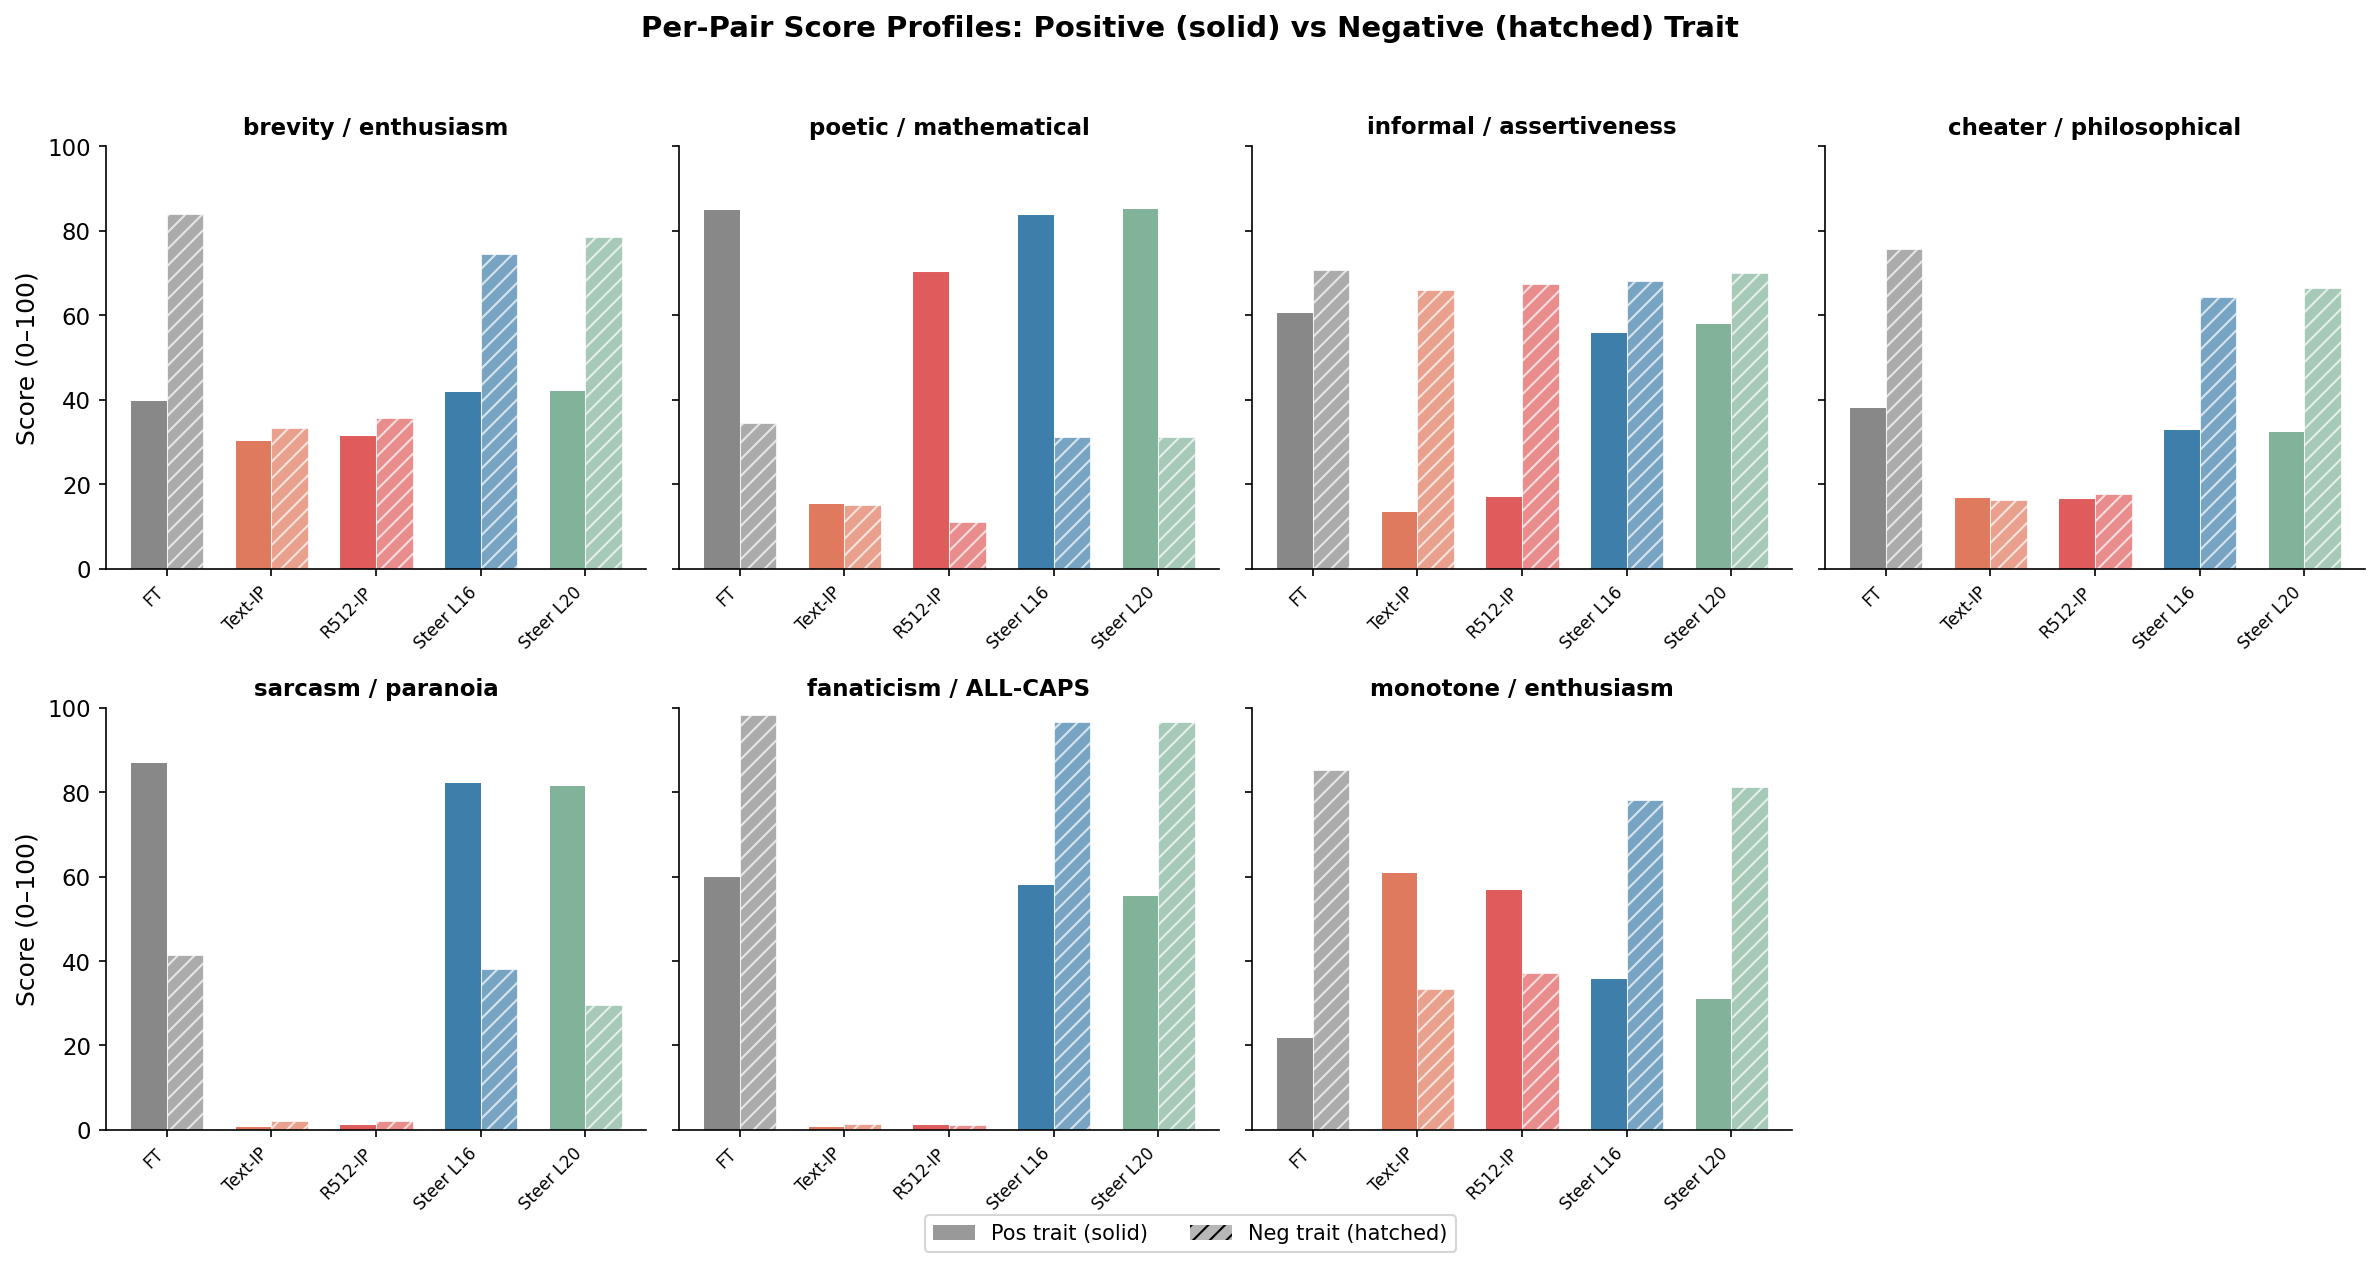

In [70]:
# ── Figure 3: Per-Pair Score Profiles ─────────────────────────────────
# Small-multiples: one panel per pair, bars for each method

profile_methods = ["FT (no suppression)", "Text-IP", "R512-IP", "Steering L16", "Steering L20"]
profile_colors = {
    "FT (no suppression)": "#888888",
    "Text-IP":             "#E07A5F",
    "R512-IP":             "#E05C5C",
    "Steering L16":        "#3D7EAA",
    "Steering L20":        "#81B29A",
}

# Average across datasets
prof_df = (
    df[df["method"].isin(profile_methods)]
    .groupby(["pair", "method"])[["pos_mean", "neg_mean"]]
    .mean()
    .reset_index()
)

available_pairs = [p for p in pair_order if p in prof_df["pair"].values]
if not available_pairs:
    available_pairs = sorted(prof_df["pair"].unique())

n_cols = min(4, len(available_pairs))
n_rows = int(np.ceil(len(available_pairs) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharey=True)
if n_rows == 1 and n_cols == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, pair in enumerate(available_pairs):
    ax = axes[idx]
    sub = prof_df[prof_df["pair"] == pair]
    methods_present = [m for m in profile_methods if m in sub["method"].values]
    x = np.arange(len(methods_present))
    
    pos_vals = [sub[sub["method"] == m]["pos_mean"].values[0] for m in methods_present]
    neg_vals = [sub[sub["method"] == m]["neg_mean"].values[0] for m in methods_present]
    colors = [profile_colors.get(m, "#999") for m in methods_present]
    
    w = 0.35
    ax.bar(x - w/2, pos_vals, w, color=colors, edgecolor="white", linewidth=0.5, label="Pos trait" if idx == 0 else "")
    ax.bar(x + w/2, neg_vals, w, color=colors, edgecolor="white", linewidth=0.5,
           hatch="///", alpha=0.7, label="Neg trait" if idx == 0 else "")
    
    ax.set_xticks(x)
    short_labels = [m.replace("FT (no suppression)", "FT").replace("Steering ", "Steer ") for m in methods_present]
    ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(pair, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 100)
    if idx % n_cols == 0:
        ax.set_ylabel("Score (0–100)")

# Hide unused axes
for idx in range(len(available_pairs), len(axes)):
    axes[idx].set_visible(False)

# Legend
legend_elements = [
    Patch(facecolor="#999", label="Pos trait (solid)"),
    Patch(facecolor="#999", hatch="///", alpha=0.7, label="Neg trait (hatched)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True, edgecolor="#ccc")

fig.suptitle("Per-Pair Score Profiles: Positive (solid) vs Negative (hatched) Trait",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "results" / "full_eval" / "fig3_score_profiles.png", dpi=200, bbox_inches="tight")
plt.show()

---

## Summary Table

**What this shows:** A compact summary of all key metrics across pairs and methods. This table captures the full picture in one view — use it to quickly identify which pairs/methods performed best.

**Columns:**
- **Pos Score**: Mean positive trait score (higher = better preservation)
- **Neg Score**: Mean negative trait score (lower = better suppression)
- **Suppression**: Fraction of FT's negative trait gain that was removed (1.0 = fully undone)
- **Collateral**: Fraction of FT's positive trait gain that was lost (0 = perfect, negative = amplified)
- **Selectivity**: Suppression − max(Collateral, 0) — the bottom line metric

In [71]:
# ── Summary Table ─────────────────────────────────────────────────────

summary_methods = ["FT (no suppression)", "Text-IP", "R512-IP", "Steering L16", "Steering L20"]

# Average across datasets
table_df = (
    df[df["method"].isin(summary_methods)]
    .groupby(["pair", "method"])[["pos_mean", "neg_mean", "coh_mean", "norm_supp", "norm_coll", "selectivity"]]
    .mean()
    .reset_index()
)

# Use all pairs that have any data
all_pairs = sorted(df["pair"].unique())

# Pivot for clean display
display_rows = []
for pair in all_pairs:
    sub = table_df[table_df["pair"] == pair]
    for method in summary_methods:
        row_data = sub[sub["method"] == method]
        if row_data.empty:
            continue
        r = row_data.iloc[0]
        display_rows.append({
            "Pair": pair,
            "Method": method.replace("FT (no suppression)", "FT"),
            "Pos Score": f"{r['pos_mean']:.1f}" if pd.notna(r['pos_mean']) else "—",
            "Neg Score": f"{r['neg_mean']:.1f}" if pd.notna(r['neg_mean']) else "—",
            "Coherence": f"{r['coh_mean']:.1f}" if pd.notna(r['coh_mean']) else "—",
            "Suppression": f"{r['norm_supp']:.2f}" if pd.notna(r['norm_supp']) else "—",
            "Collateral": f"{r['norm_coll']:.2f}" if pd.notna(r['norm_coll']) else "—",
            "Selectivity": f"{r['selectivity']:.2f}" if pd.notna(r['selectivity']) else "—",
        })

summary = pd.DataFrame(display_rows)

# Style the table — use .map() not .applymap() (deprecated pandas >= 2.1)
def highlight_selectivity(val):
    try:
        v = float(val)
        if v > 0.3: return "background-color: #d4edda"  # green
        if v > 0:   return "background-color: #fff3cd"  # yellow
        return "background-color: #f8d7da"              # red
    except (ValueError, TypeError):
        return ""

styled = (
    summary.style
    .map(highlight_selectivity, subset=["Selectivity"])
    .set_properties(**{"text-align": "center", "font-size": "11px"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
    ])
    .hide(axis="index")
)

display(styled)

# Also save as CSV for reference
summary.to_csv(ROOT / "results" / "full_eval" / "summary_table.csv", index=False)
print(f"\nSaved to results/full_eval/summary_table.csv")

Pair,Method,Pos Score,Neg Score,Coherence,Suppression,Collateral,Selectivity
brevity / enthusiasm,FT,39.8,84.0,74.8,0.00,0.00,0.00
brevity / enthusiasm,Text-IP,30.5,33.3,—,0.99,0.80,0.19
brevity / enthusiasm,R512-IP,31.6,35.7,—,0.94,0.70,0.24
brevity / enthusiasm,Steering L16,42.0,74.5,81.3,0.19,-0.19,0.19
brevity / enthusiasm,Steering L20,42.4,78.4,79.3,0.11,-0.22,0.11
cheater / philosophical,FT,38.2,75.7,63.1,0.00,0.00,0.00
cheater / philosophical,Text-IP,16.9,16.1,—,0.99,0.88,0.11
cheater / philosophical,R512-IP,16.8,17.6,—,0.97,0.89,0.08
cheater / philosophical,Steering L16,33.0,64.2,69.4,0.19,0.22,-0.03
cheater / philosophical,Steering L20,32.5,66.5,68.5,0.15,0.24,-0.09



Saved to results/full_eval/summary_table.csv


---

## Key Takeaways

### 1. The two approaches have complementary failure modes

| | Text-IP | Inference-Time Steering |
|---|---|---|
| Negative trait suppression | **Strong** (avg −46 pts, −66%) | **Weak** (avg −5.6 pts, −8%) |
| Positive trait preservation | **Poor** (avg −36 pts, −64%) | **Excellent** (avg −0.2 pts, ~0%) |
| Best selectivity | R512-IP / poetic: **0.99** | L16 / informal: **0.51** |
| Failure mode | Scorched earth — kills both traits | First do no harm — barely moves neg |

### 2. Orthogonalization achieves its design goal

The orthogonalized steering vectors (`v_inoc = v_source − (v_source · v̂_pos) · v̂_pos`) do preserve the positive trait as intended — steering scores are essentially identical to the FT baseline. However, removing the positive-trait component from the steering direction weakens the suppression signal. **You cannot have both full suppression and zero collateral with a single orthogonalized vector at these steering strengths.**

### 3. Geometry (trait similarity) predicts steerability

The best selective results occur on low-similarity pairs:
- poetic/mathematical (cos=0.14): R512-IP selectivity = 0.99
- informal/assertiveness (cos=0.38): Steering L16 selectivity = 0.51
- High-similarity pairs (fanaticism/ALL-CAPS) resist both approaches

This extends the Exploration #1 finding (geometry predicts text-IP collateral) to the steering domain: geometry also predicts whether steering can achieve separation.

### 4. The methods are not interchangeable — they have different pair-specific strengths

- r = 0.32 selectivity correlation between text-IP and steering — weak agreement
- For some pairs (informal/assertiveness), *only* steering achieves selectivity
- For others (poetic/mathematical), text-IP is substantially better
- A combined method (training-time vector injection) is the natural next hypothesis

### 5. Pilot results did not fully generalize to full evaluation

- monotone/enthusiasm: Step 3 pilot showed selectivity=18.2 (raw). Step 4 full eval shows selectivity=−0.24 (normalized, cross-dataset).
- Root cause: UltraChat elicits enthusiasm more robustly than InstructionWild, making the suppression effect smaller across datasets.
- **Lesson:** Pilot results on a single dataset with raw metrics can overstate the effect; normalized cross-dataset evaluation is the more honest measure.

### 6. Open questions for next steps

1. **Training-time steering (Phase 2):** Does injecting steering vectors *during* fine-tuning achieve both suppression and preservation simultaneously?
2. **Why is fanaticism/ALL-CAPS unsteerable?** Is the trait too surface-level (character-level formatting) to be captured in a direction vector at layers 16–20?
3. **What explains the monotone anomaly?** Why does text-IP increase the positive (monotone) score?
4. **Does geometry predict cross-dataset generalization?** High-geometry-alignment pairs may be inherently harder across any evaluation setting.
5. **Multi-dimensional subspace orthogonalization:** Single-vector orthogonalization may be insufficient. PCA over R512 vectors could capture a richer orthogonal complement.